# <font size="5">Import

In [1]:
import os
import os.path
import sys
from sys import platform
from shutil import copyfile
import socket
import psutil
import GPUtil
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from scipy.ndimage import gaussian_filter,rotate
from tifffile import imread, TiffFile, imsave
from PIL import Image
import copy
import cv2
import warnings
import timeit
import pickle
from matplotlib.backends.backend_pdf import PdfPages
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['pdf.fonttype'] = 42
import sled_general_tools
import sled_image_tools
import moviepy
from moviepy.video.io import VideoFileClip
from datetime import datetime
from io import BytesIO
import matplotlib.animation as animation
from tqdm import tqdm

In [2]:
filePath = "/export/disk1/pooledData/ReLOAD/EOD_250822"
fileName = "5khz-ms-round2_00037_00001.tif"
fileName = "5khz-ms-round2_00037_00010.tif"
refImgFile = "M_2out-blk_nor.png"
scanImage = "scanning.bmp"

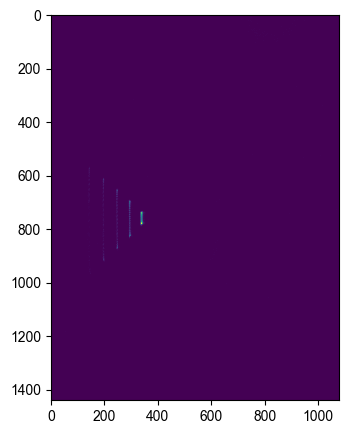

In [3]:
scanImg = Image.open(os.path.join(filePath,scanImage))
plt.figure(figsize = (5,5))
plt.imshow(scanImg,interpolation='none')

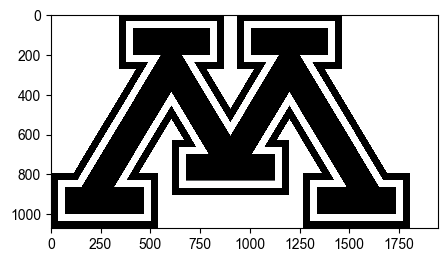

In [4]:
refImg = Image.open(os.path.join(filePath,refImgFile))
plt.figure(figsize = (5,5))
plt.imshow(refImg,interpolation='none')

In [5]:

tiff = TiffFile(os.path.join(filePath,fileName))
width = tiff.pages[0].imagewidth
height = tiff.pages[0].imagelength
dtype = tiff.pages[0].dtype
nframes = int(len(tiff.pages))
data=imread(os.path.join(filePath,fileName))
data_meanProj = np.nanmean(data,axis=0)
tiff.close()


<tifffile.TiffFile '5khz-ms-round2_00037_00010.tif'> asarray failed to reshape (1000, 190, 72) to (50000, 190, 72)


# <font size="5">Bidir EOD Correction

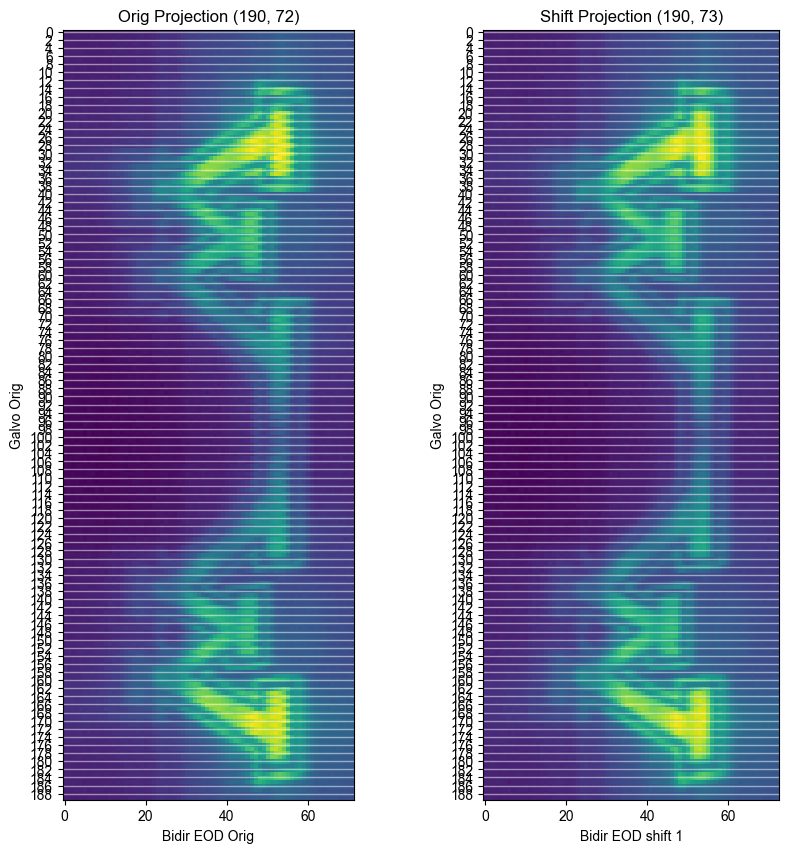

In [6]:
EOD_axis_px_shift = 1 #Operates on ODD indices
data_EOD_Shifted = np.ones((data.shape[0],data.shape[1],data.shape[2]+np.absolute(EOD_axis_px_shift)),dtype='float32')*np.nan
for y in range(data.shape[1]):
    if EOD_axis_px_shift > 0:
        if np.mod(y,2) == 0:
            data_EOD_Shifted[:,y,0:data.shape[2]] = data[:,y,0:data.shape[2]]
            for x in range(data.shape[2],data.shape[2]+np.absolute(EOD_axis_px_shift)):
                data_EOD_Shifted[:,y,x] = data[:,y,data.shape[2]-1]
        else:
            data_EOD_Shifted[:,y,np.absolute(EOD_axis_px_shift):data.shape[2]+np.absolute(EOD_axis_px_shift)] = data[:,y,0:data.shape[2]]
            for x in range(0,np.absolute(EOD_axis_px_shift)):
                data_EOD_Shifted[:,y,x] = data[:,y,0]
    elif EOD_axis_px_shift < 0:
        if np.mod(y,2) == 0:
            data_EOD_Shifted[:,y,np.absolute(EOD_axis_px_shift):data.shape[2]+np.absolute(EOD_axis_px_shift)] = data[:,y,0:data.shape[2]]
        else:
            data_EOD_Shifted[:,y,0:data.shape[2]] = data[:,y,0:data.shape[2]]
    else:
        data_EOD_Shifted[:,y,0:data.shape[2]] = data[:,y,0:data.shape[2]]
data_EOD_Shifted_meanProj = np.nanmean(data_EOD_Shifted,axis=0)
fig,ax = plt.subplots(1,2,figsize = (10,10))
ax[0].imshow(data_meanProj,interpolation='none')
ax[0].set_ylabel("Galvo Orig")
ax[0].set_xlabel("Bidir EOD Orig")
ax[0].set_title("Orig Projection "+str(data_meanProj.shape))
ax[0].set_yticks(np.arange(0, data_meanProj.shape[0], 2))
ax[0].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5,axis = 'y')
ax[1].imshow(data_EOD_Shifted_meanProj,interpolation='none')
ax[1].set_ylabel("Galvo Orig")
ax[1].set_xlabel("Bidir EOD shift "+str(EOD_axis_px_shift))
ax[1].set_title("Shift Projection "+str(data_EOD_Shifted_meanProj.shape))
ax[1].set_yticks(np.arange(0, data_EOD_Shifted_meanProj.shape[0], 2))
ax[1].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5,axis = 'y')


# <font size="5">Bidir EOD Padding

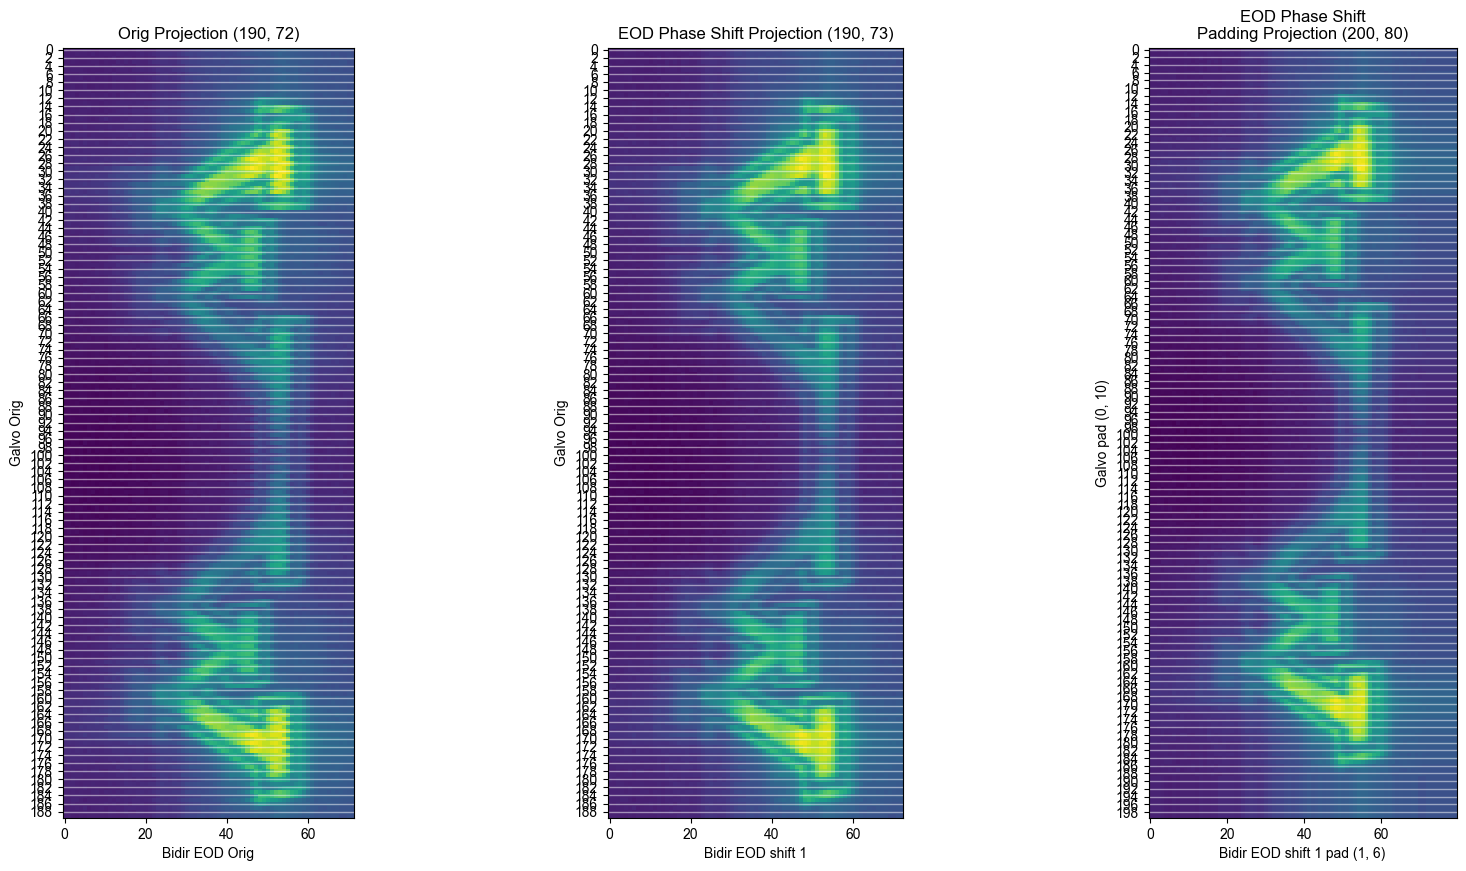

In [7]:
EOD_padding = (1,6)
galvo_padding = (0,10)
data_EOD_Shifted_pad = np.pad(data_EOD_Shifted, ((0,0), (0, 0), EOD_padding), 'edge')
data_EOD_Shifted_pad = np.pad(data_EOD_Shifted_pad, ((0,0), galvo_padding, (0, 0)), 'edge')
data_EOD_Shifted_pad_meanProj = np.nanmean(data_EOD_Shifted_pad,axis=0)

fig,ax = plt.subplots(1,3,figsize = (20,10))
ax[0].imshow(data_meanProj,interpolation='none')
ax[0].set_ylabel("Galvo Orig")
ax[0].set_xlabel("Bidir EOD Orig")
ax[0].set_title("Orig Projection "+str(data_meanProj.shape))
ax[0].set_yticks(np.arange(0, data_meanProj.shape[0], 2))
ax[0].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5,axis = 'y')
ax[1].imshow(data_EOD_Shifted_meanProj,interpolation='none')
ax[1].set_ylabel("Galvo Orig")
ax[1].set_xlabel("Bidir EOD shift "+str(EOD_axis_px_shift))
ax[1].set_title("EOD Phase Shift Projection "+str(data_EOD_Shifted_meanProj.shape))
ax[1].set_yticks(np.arange(0, data_EOD_Shifted_meanProj.shape[0], 2))
ax[1].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5,axis = 'y')
ax[2].imshow(data_EOD_Shifted_pad_meanProj,interpolation='none')
ax[2].set_ylabel("Galvo pad "+str(galvo_padding))
ax[2].set_xlabel("Bidir EOD shift "+str(EOD_axis_px_shift)+" pad "+str(EOD_padding))
ax[2].set_title("EOD Phase Shift\nPadding Projection "+str(data_EOD_Shifted_pad_meanProj.shape))
ax[2].set_yticks(np.arange(0, data_EOD_Shifted_pad_meanProj.shape[0], 2))
ax[2].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5,axis = 'y')


# <font size="5">No EOD Unfolded Correction

(-1.0, 80.0)

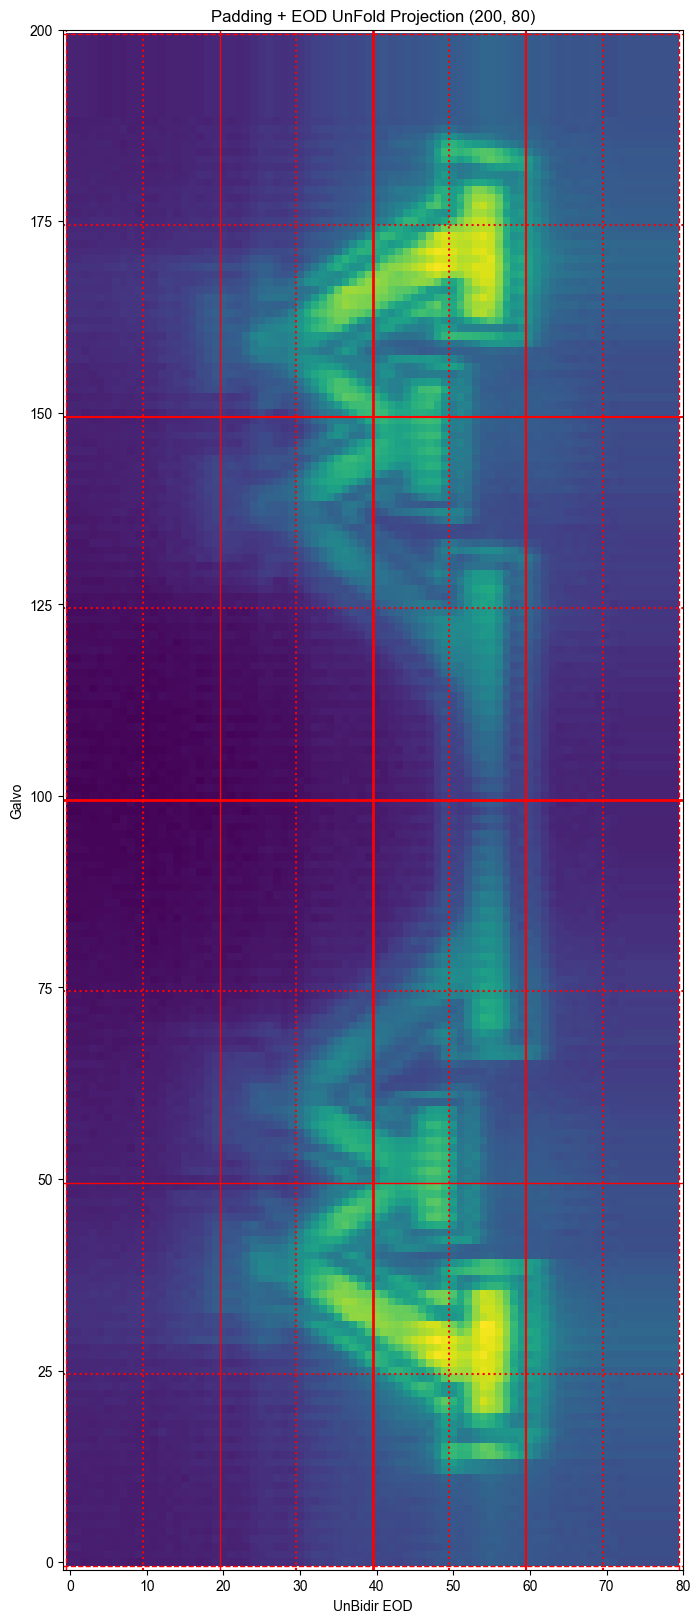

In [8]:
plt.figure(figsize = (20,20))
plt.imshow(data_EOD_Shifted_pad_meanProj,interpolation='none',)
plt.axvline(np.floor(data_EOD_Shifted_pad_meanProj.shape[1]*(0/8))-0.5,lw = 1,linestyle='--',color =(1,0,0))
plt.axvline(np.floor(data_EOD_Shifted_pad_meanProj.shape[1]*(1/8))-0.5,linestyle=':',color =(1,0,0))
plt.axvline(np.floor(data_EOD_Shifted_pad_meanProj.shape[1]*(2/8))-0.5,lw = 1, color =(1,0,0))
plt.axvline(np.floor(data_EOD_Shifted_pad_meanProj.shape[1]*(3/8))-0.5,linestyle=':',color =(1,0,0))
plt.axvline(np.round(data_EOD_Shifted_pad_meanProj.shape[1]*(4/8))-0.5,lw = 2, color =(1,0,0))
plt.axvline(np.ceil(data_EOD_Shifted_pad_meanProj.shape[1]*(5/8))-0.5,linestyle=':',color =(1,0,0))
plt.axvline(np.ceil(data_EOD_Shifted_pad_meanProj.shape[1]*(6/8))-0.5,color =(1,0,0))
plt.axvline(np.ceil(data_EOD_Shifted_pad_meanProj.shape[1]*(7/8))-0.5,linestyle=':',color =(1,0,0))
plt.axvline(np.ceil(data_EOD_Shifted_pad_meanProj.shape[1]*(8/8))-0.5,lw = 1,linestyle='--',color =(1,0,0))
plt.axhline(np.floor(data_EOD_Shifted_pad_meanProj.shape[0]*(0/8))-0.5,lw = 1,linestyle='--',color =(1,0,0))
plt.axhline(np.floor(data_EOD_Shifted_pad_meanProj.shape[0]*(1/8))-0.5,linestyle=':',color =(1,0,0))
plt.axhline(np.floor(data_EOD_Shifted_pad_meanProj.shape[0]*(2/8))-0.5,lw = 1, color =(1,0,0))
plt.axhline(np.floor(data_EOD_Shifted_pad_meanProj.shape[0]*(3/8))-0.5,linestyle=':',color =(1,0,0))
plt.axhline(np.round(data_EOD_Shifted_pad_meanProj.shape[0]*(4/8))-0.5,lw = 2, color =(1,0,0))
plt.axhline(np.ceil(data_EOD_Shifted_pad_meanProj.shape[0]*(5/8))-0.5,linestyle=':',color =(1,0,0))
plt.axhline(np.ceil(data_EOD_Shifted_pad_meanProj.shape[0]*(6/8))-0.5,color =(1,0,0))
plt.axhline(np.ceil(data_EOD_Shifted_pad_meanProj.shape[0]*(7/8))-0.5,linestyle=':',color =(1,0,0))
plt.axhline(np.ceil(data_EOD_Shifted_pad_meanProj.shape[0]*(8/8))-0.5,lw = 1,linestyle='--',color =(1,0,0))
plt.ylabel("Galvo")
plt.xlabel("UnBidir EOD")
plt.title("Padding + EOD UnFold Projection "+str(data_EOD_Shifted_pad_meanProj.shape))
plt.ylim([-1,data_EOD_Shifted_pad_meanProj.shape[0]])
plt.xlim([-1,data_EOD_Shifted_pad_meanProj.shape[1]])

In [9]:
EOD_bidir_turn_px = 80

EOD_distortion_factor = 0.3 * np.array([-1, 1])
EOD_correction_freq = 0.5
EOD_phase_shift = False
EOD_correction_phase_shift_px = 0
EOD_correction_shift_px = 0
EOD_distortion = 'sin' #cos
EOD_interpolation = cv2.INTER_LINEAR

galvo_bidir_turn_px = 100
# galvo_distortion_factor = 0.2 * np.array([-1, 1, -1, 1])
# galvo_correction_freq = 0.8
# galvo_phase_shift = True
# galvo_correction_phase_shift_px = -25
galvo_distortion_factor = 0.2 * np.array([-1, 1, -1, 1])
galvo_correction_freq = 0.9
galvo_phase_shift = True
galvo_correction_phase_shift_px = -12
galvo_correction_shift_px = 0
galvo_distortion = 'sin' #cos
galvo_interpolation = cv2.INTER_LINEAR

galvo_correction_phase_shift = -0.33929200658769765


(200.0, 0.0)

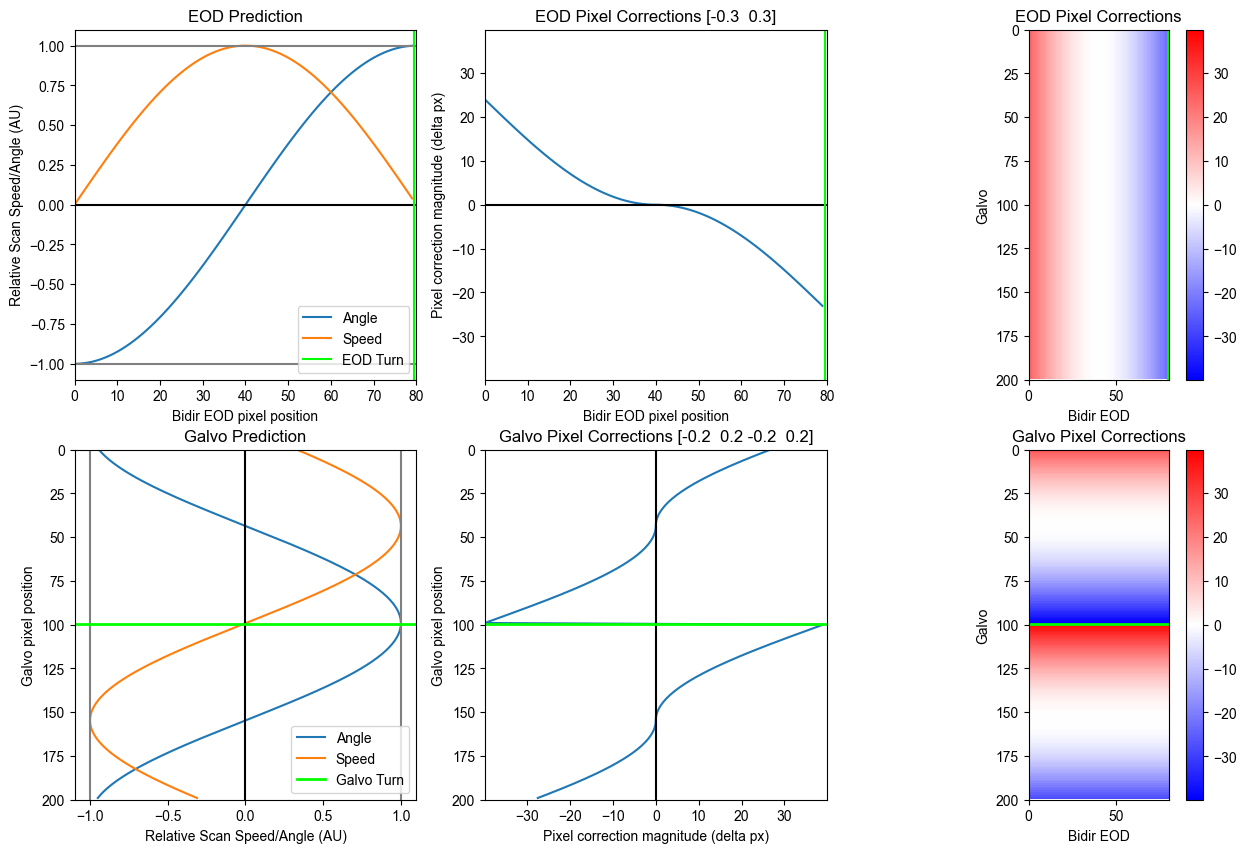

In [10]:
EOD_xdata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[1])
EOD_rel_xdata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[1])-EOD_bidir_turn_px
h, w = data_EOD_Shifted_pad_meanProj.shape[:2]
EOD_orig_map_x, EOD_orig_map_y = np.meshgrid(np.arange(w), np.arange(h))
if EOD_phase_shift:
    EOD_correction_phase_shift = (EOD_correction_phase_shift_px/w)* 2 * np.pi * EOD_correction_freq
    print(f'EOD_correction_phase_shift = {EOD_correction_phase_shift}')
else:
    EOD_correction_phase_shift = 0
x1_norm = ((EOD_orig_map_x) / (w)) * 2 * np.pi * EOD_correction_freq
if EOD_distortion == 'sin':
    EOD_distortion_field = np.sin(x1_norm-EOD_correction_phase_shift) * w
    EOD_speed = np.sin(x1_norm[0,:]-EOD_correction_phase_shift)
    EOD_angle = np.cos(x1_norm[0,:]-EOD_correction_phase_shift) * -1
else:
    EOD_distortion_field = np.cos(x1_norm-EOD_correction_phase_shift) * w
    EOD_speed = np.cos(x1_norm[0,:]-EOD_correction_phase_shift)
    EOD_angle = np.sin(x1_norm[0,:]-EOD_correction_phase_shift) * -1
##############################################################
EOD_distortion_field = np.absolute(np.absolute(EOD_distortion_field)-w)
# EOD_distortion_field = (EOD_distortion_field - np.nanmax(EOD_distortion_field))
EOD_distortion_field[:,0:np.nanargmax(EOD_speed)] = EOD_distortion_field[:,0:np.nanargmax(EOD_speed)] * EOD_distortion_factor[0]
EOD_distortion_field[:,np.nanargmax(EOD_speed):w] = EOD_distortion_field[:,np.nanargmax(EOD_speed):w] * EOD_distortion_factor[1]
# EOD_distortion_field[:,int(w/2):np.nanargmin(EOD_speed)] = EOD_distortion_field[:,int(w/2):np.nanargmin(EOD_speed)] * EOD_distortion_factor[2]
# EOD_distortion_field[:,np.nanargmin(EOD_speed):w] = EOD_distortion_field[:,np.nanargmin(EOD_speed):w] * EOD_distortion_factor[3]
EOD_correction_map = EOD_orig_map_x + EOD_distortion_field
EOD_correction_map_x = EOD_correction_map.astype(np.float32)
EOD_orig_map_y = EOD_orig_map_y.astype(np.float32)
data_EOD_ShiftedCorrected_meanProj = cv2.remap(data_EOD_Shifted_pad_meanProj, EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation)
EOD_distortion_correction = EOD_orig_map_x-EOD_correction_map_x
##############################################################
galvo_ydata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[0])
galvo_rel_ydata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[0])-galvo_bidir_turn_px
h, w = data_EOD_Shifted_pad_meanProj.shape[:2]
galvo_orig_map_x, galvo_orig_map_y = np.meshgrid(np.arange(w), np.arange(h))
if galvo_phase_shift:
    galvo_correction_phase_shift = (galvo_correction_phase_shift_px/h)* 2 * np.pi * galvo_correction_freq
    print(f'galvo_correction_phase_shift = {galvo_correction_phase_shift}')
else:
    galvo_correction_phase_shift = 0
y1_norm = ((galvo_orig_map_y) / (h)) * 2 * np.pi * galvo_correction_freq
if galvo_distortion == 'sin':
    galvo_distortion_field = np.sin(y1_norm-galvo_correction_phase_shift) * h
    galvo_speed = np.sin(y1_norm[:,0]-galvo_correction_phase_shift)
    galvo_angle = np.cos(y1_norm[:,0]-galvo_correction_phase_shift) * -1
else:
    galvo_distortion_field = np.cos(y1_norm-galvo_correction_phase_shift) * h
    galvo_speed = np.cos(y1_norm[:,0]-galvo_correction_phase_shift)
    galvo_angle = np.sin(y1_norm[:,0]-galvo_correction_phase_shift) * -1
##############################################################
galvo_distortion_field = np.absolute(np.absolute(galvo_distortion_field)-h)
# galvo_distortion_field = (galvo_distortion_field - np.nanmax(galvo_distortion_field))
galvo_distortion_field[0:np.nanargmax(galvo_speed),:] = galvo_distortion_field[0:np.nanargmax(galvo_speed),:] * galvo_distortion_factor[0]
galvo_distortion_field[np.nanargmax(galvo_speed):int(h/2),:] = galvo_distortion_field[np.nanargmax(galvo_speed):int(h/2),:] * galvo_distortion_factor[1]
galvo_distortion_field[int(h/2):np.nanargmin(galvo_speed),:] = galvo_distortion_field[int(h/2):np.nanargmin(galvo_speed),:] * galvo_distortion_factor[2]
galvo_distortion_field[np.nanargmin(galvo_speed):h,:] = galvo_distortion_field[np.nanargmin(galvo_speed):h,:] * galvo_distortion_factor[3]
galvo_correction_map = galvo_orig_map_y + galvo_distortion_field
galvo_correction_map_y = galvo_correction_map.astype(np.float32)
galvo_orig_map_x = galvo_orig_map_x.astype(np.float32)
data_EOD_ShiftedCorrected_meanProj = cv2.remap(data_EOD_Shifted_pad_meanProj, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
galvo_distortion_correction = galvo_orig_map_y-galvo_correction_map_y
max_distortion_correction = np.max([np.max(np.absolute(EOD_distortion_correction)), np.max(np.absolute(galvo_distortion_correction))])
##############################################################
fig,ax = plt.subplots(2,3,figsize = (15,10))
ax[0,0].plot(EOD_xdata,EOD_angle,label='Angle')
ax[0,0].plot(EOD_xdata,EOD_speed,label='Speed')
ax[0,0].axhline(-1,color = (0.5,0.5,0.5))
ax[0,0].axhline(0,color = (0,0,0))
ax[0,0].axhline(1,color = (0.5,0.5,0.5))
ax[0,0].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),label='EOD Turn')
ax[0,0].legend()
ax[0,0].set_xlim([0,data_EOD_Shifted_pad_meanProj.shape[1]])
ax[0,0].set_title('EOD Prediction')
ax[0,0].set_xlabel('Bidir EOD pixel position')
ax[0,0].set_ylabel('Relative Scan Speed/Angle (AU)')

ax[0,1].plot(EOD_xdata,EOD_distortion_field[0,:]*-1)
ax[0,1].axhline(0,color = (0,0,0))
ax[0,1].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0))
ax[0,1].set_xlim([0,data_EOD_Shifted_pad_meanProj.shape[1]])
ax[0,1].set_ylim([-1*max_distortion_correction,max_distortion_correction])
ax[0,1].set_title('EOD Pixel Corrections '+str(EOD_distortion_factor))
ax[0,1].set_xlabel('Bidir EOD pixel position')
ax[0,1].set_ylabel('Pixel correction magnitude (delta px)')

im = ax[0,2].imshow(EOD_distortion_correction,interpolation='none',cmap='bwr',\
           vmin=-1*max_distortion_correction,vmax=max_distortion_correction)
plt.colorbar(im)
# ax[0,2].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5)
ax[0,2].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[0,2].set_title('EOD Pixel Corrections')
ax[0,2].set_xlabel('Bidir EOD')
ax[0,2].set_ylabel('Galvo')
ax[0,2].set_xlim([0,EOD_distortion_correction.shape[1]])
ax[0,2].set_ylim([EOD_distortion_correction.shape[0],0])

ax[1,0].plot(galvo_angle,galvo_ydata,label='Angle')
ax[1,0].plot(galvo_speed,galvo_ydata,label='Speed')
ax[1,0].axvline(-1,color = (0.5,0.5,0.5))
ax[1,0].axvline(0,color = (0,0,0))
ax[1,0].axvline(1,color = (0.5,0.5,0.5))
ax[1,0].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2,label='Galvo Turn')
ax[1,0].legend()
ax[1,0].set_ylim([data_EOD_Shifted_pad_meanProj.shape[0],0])
ax[1,0].set_title('Galvo Prediction')
ax[1,0].set_ylabel('Galvo pixel position')
ax[1,0].set_xlabel('Relative Scan Speed/Angle (AU)')

ax[1,1].plot(galvo_distortion_field[:,0]*-1,galvo_ydata)
ax[1,1].axvline(0,color = (0,0,0))
ax[1,1].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[1,1].set_ylim([data_EOD_Shifted_pad_meanProj.shape[0],0])
ax[1,1].set_xlim([-1*max_distortion_correction,max_distortion_correction])
ax[1,1].set_title('Galvo Pixel Corrections '+str(galvo_distortion_factor))
ax[1,1].set_ylabel('Galvo pixel position')
ax[1,1].set_xlabel('Pixel correction magnitude (delta px)')

im = ax[1,2].imshow(galvo_distortion_correction,interpolation='none',cmap='bwr',\
           vmin=-1*max_distortion_correction,vmax=max_distortion_correction)
ax[1,2].invert_yaxis()
plt.colorbar(im)
ax[1,2].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[1,2].set_title('Galvo Pixel Corrections')
ax[1,2].set_xlabel('Bidir EOD')
ax[1,2].set_ylabel('Galvo')
ax[1,2].set_xlim([0,galvo_distortion_correction.shape[1]])
ax[1,2].set_ylim([galvo_distortion_correction.shape[0],0])


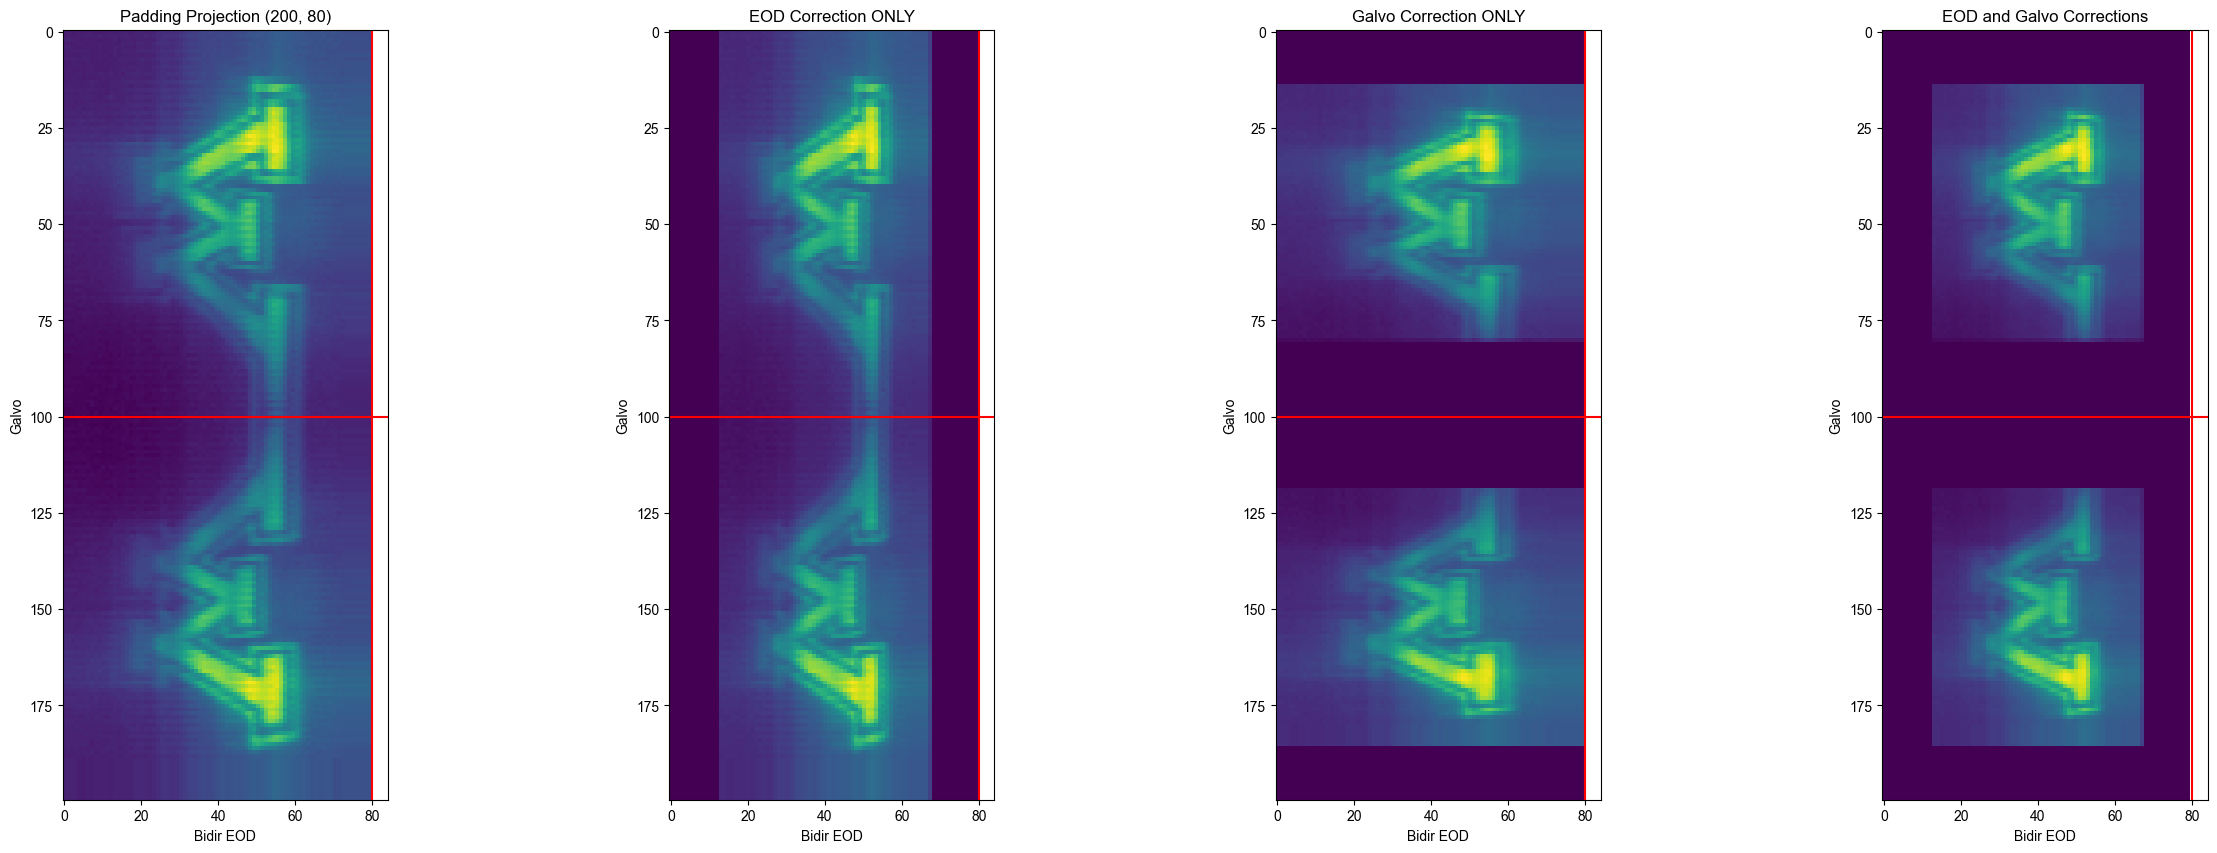

In [11]:
# data_EOD_Shifted_pad_EODCorr = np.ones_like(data_EOD_Shifted_pad)*np.nan
data_EOD_Shifted_pad_EODCorr = np.zeros_like(data_EOD_Shifted_pad)
for t in range(data_EOD_Shifted_pad.shape[0]):
    # data_EOD_Shifted_pad_EODCorr[t,:,0:EOD_bidir_turn_px] = cv2.remap(data_EOD_Shifted_pad[t,:,0:EOD_bidir_turn_px], EOD_correction_map_x[:,0:EOD_bidir_turn_px], EOD_orig_map_y[:,0:EOD_bidir_turn_px], EOD_interpolation)
    # data_EOD_Shifted_pad_EODCorr[t,:,EOD_bidir_turn_px:data_EOD_Shifted_pad.shape[2]] = cv2.remap(data_EOD_Shifted_pad[t,:,EOD_bidir_turn_px:data_EOD_Shifted_pad.shape[2]], EOD_correction_map_x[:,EOD_bidir_turn_px:data_EOD_Shifted_pad.shape[2]], EOD_orig_map_y[:,EOD_bidir_turn_px:data_EOD_Shifted_pad.shape[2]], EOD_interpolation)
    # data_EOD_Shifted_pad_EODCorr[t,:,:] = cv2.remap(data_EOD_Shifted_pad[t,:,:], EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation)
    tempImg = copy.deepcopy(data_EOD_Shifted_pad[t,:,:])
    # tempImg[:,EOD_bidir_turn_px-1:data_EOD_Shifted_pad.shape[2]] = 0
    tempImg = cv2.remap(tempImg, EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation)
    # tempImg[:,EOD_bidir_turn_px-1:data_EOD_Shifted_pad.shape[2]] = 0
    data_EOD_Shifted_pad_EODCorr[t,:,:] = data_EOD_Shifted_pad_EODCorr[t,:,:] + tempImg
    # tempImg = copy.deepcopy(data_EOD_Shifted_pad[t,:,:])
    # # tempImg[:,0:EOD_bidir_turn_px] = 0
    # tempImg = cv2.remap(tempImg, EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation)
    # # tempImg[:,0:EOD_bidir_turn_px] = 0
    # data_EOD_Shifted_pad_EODCorr[t,:,:] = data_EOD_Shifted_pad_EODCorr[t,:,:] + tempImg
data_EOD_Shifted_pad_EODCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_EODCorr,axis=0)
##############################################################
data_EOD_Shifted_pad_GalvoCorr = np.zeros_like(data_EOD_Shifted_pad)
for t in range(data_EOD_Shifted_pad.shape[0]):
    tempImg = copy.deepcopy(data_EOD_Shifted_pad[t,:,:])
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad.shape[1],:] = 0
    tempImg = cv2.remap(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad.shape[1],:] = 0
    data_EOD_Shifted_pad_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_GalvoCorr[t,:,:] + tempImg
    tempImg = copy.deepcopy(data_EOD_Shifted_pad[t,:,:])
    tempImg[0:galvo_bidir_turn_px,:] = 0
    tempImg = cv2.remap(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg[0:galvo_bidir_turn_px,:] = 0
    data_EOD_Shifted_pad_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_GalvoCorr[t,:,:] + tempImg
data_EOD_Shifted_pad_GalvoCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_GalvoCorr,axis=0)
##############################################################
data_EOD_Shifted_pad_EODCorr_GalvoCorr = np.zeros_like(data_EOD_Shifted_pad)
for t in range(data_EOD_Shifted_pad.shape[0]):
    # data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:] = cv2.remap(data_EOD_Shifted_pad_EODCorr[t,:,:], galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    # data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:] = cv2.remap(data_EOD_Shifted_pad_EODCorr[t,:,:], galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_EODCorr[t,:,:])
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad.shape[1],:] = 0
    tempImg = cv2.remap(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad.shape[1],:] = 0
    data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:] + tempImg
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_EODCorr[t,:,:])
    tempImg[0:galvo_bidir_turn_px,:] = 0
    tempImg = cv2.remap(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg[0:galvo_bidir_turn_px,:] = 0
    data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:] + tempImg  
data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_EODCorr_GalvoCorr,axis=0)
##############################################################
fig,ax = plt.subplots(1,4,figsize = (30,10))
ax[0].imshow(data_EOD_Shifted_pad_meanProj,interpolation='none')
ax[0].set_ylabel("Galvo")
ax[0].set_xlabel("Bidir EOD")
ax[0].set_title("Padding Projection "+str(data_EOD_Shifted_pad_meanProj.shape))
ax[0].axvline(EOD_bidir_turn_px,color ='r')
ax[0].axhline(galvo_bidir_turn_px,color ='r')
ax[1].imshow(data_EOD_Shifted_pad_EODCorr_meanProj,interpolation='none')
ax[1].set_ylabel("Galvo")
ax[1].set_xlabel("Bidir EOD")
ax[1].set_title("EOD Correction ONLY")
ax[1].axvline(EOD_bidir_turn_px,color ='r')
ax[1].axhline(galvo_bidir_turn_px,color ='r')
ax[2].imshow(data_EOD_Shifted_pad_GalvoCorr_meanProj,interpolation='none')
ax[2].set_ylabel("Galvo")
ax[2].set_xlabel("Bidir EOD")
ax[2].set_title("Galvo Correction ONLY")
ax[2].axvline(EOD_bidir_turn_px,color ='r')
ax[2].axhline(galvo_bidir_turn_px,color ='r')
ax[3].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj,interpolation='none')
ax[3].set_ylabel("Galvo")
ax[3].set_xlabel("Bidir EOD")
ax[3].set_title("EOD and Galvo Corrections")
ax[3].axvline(EOD_bidir_turn_px,color ='r')
ax[3].axhline(galvo_bidir_turn_px,color ='r')

In [12]:
EOD_Upscale = 5
Galvo_Upscale = 5
temp = cv2.resize(data_EOD_Shifted_pad_meanProj, (0,0), fx=EOD_Upscale, fy=Galvo_Upscale)
data_EOD_Shifted_pad_Up = np.ones((data_EOD_Shifted_pad.shape[0],temp.shape[0],temp.shape[1]))*np.nan
for t in range(data_EOD_Shifted_pad.shape[0]):
    data_EOD_Shifted_pad_Up[t,:,:] = cv2.resize(data_EOD_Shifted_pad[t,:,:], (0,0), fx=EOD_Upscale, fy=Galvo_Upscale)
data_EOD_Shifted_pad_Up_meanProj = np.nanmean(data_EOD_Shifted_pad_Up,axis=0)


In [13]:
EOD_bidir_turn_px = 400
EOD_distortion_factor = 0.3 * np.array([-1, 1])
EOD_correction_freq = 0.5
EOD_phase_shift = False
EOD_correction_phase_shift_px = 0
EOD_correction_shift_px = 0
EOD_distortion = 'sin' #cos
EOD_interpolation = cv2.INTER_LINEAR

galvo_bidir_turn_px = 500
# galvo_distortion_factor = 0.2 * np.array([-1, 1, -1, 1])
# galvo_correction_freq = 0.8
# galvo_phase_shift = True
# galvo_correction_phase_shift_px = -25
galvo_distortion_factor = 0.2 * np.array([-1, 1, -1, 1])
galvo_correction_freq = 0.9
galvo_phase_shift = True
galvo_correction_phase_shift_px = -60
galvo_correction_shift_px = 0
galvo_distortion = 'sin' #cos
galvo_interpolation = cv2.INTER_LINEAR

galvo_correction_phase_shift = -0.33929200658769765


(1000.0, 0.0)

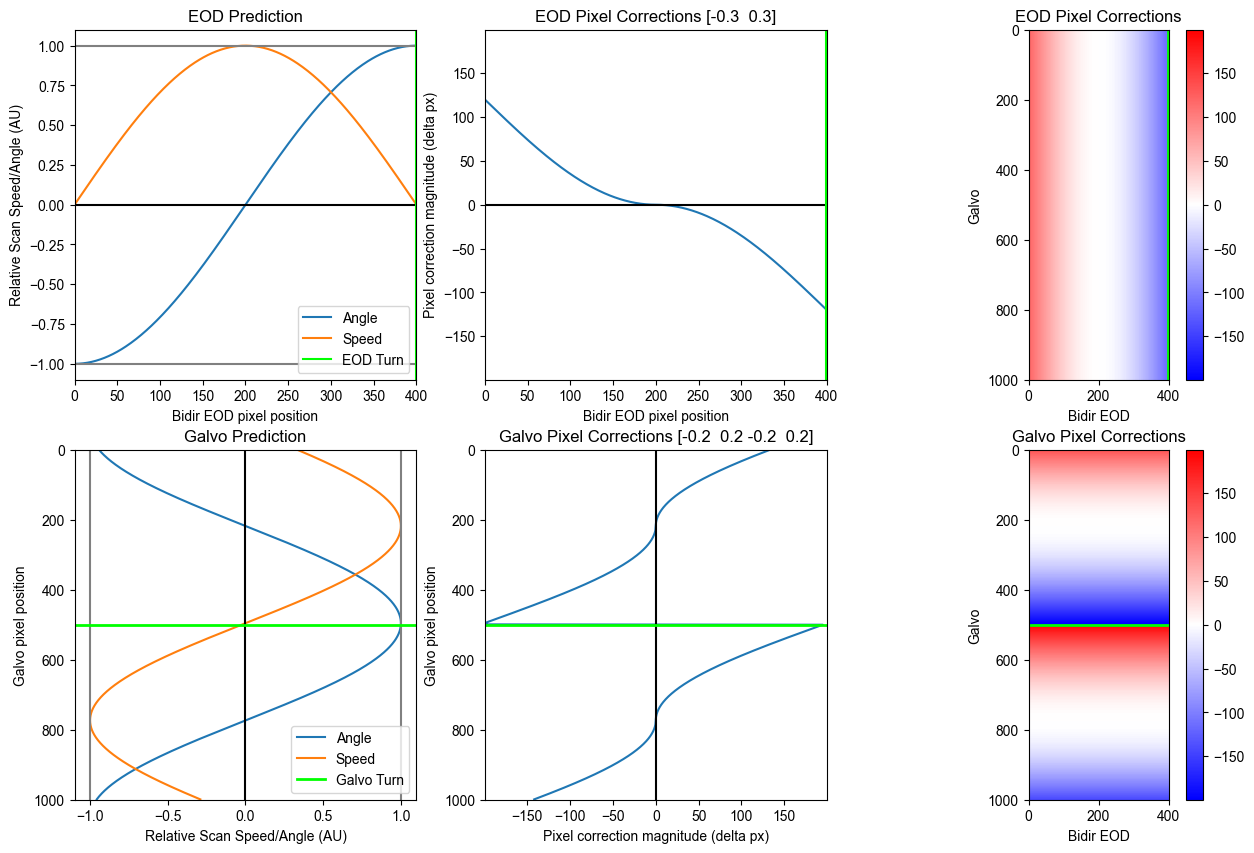

In [14]:
EOD_xdata = np.arange(0,data_EOD_Shifted_pad_Up_meanProj.shape[1])
EOD_rel_xdata = np.arange(0,data_EOD_Shifted_pad_Up_meanProj.shape[1])-EOD_bidir_turn_px
h, w = data_EOD_Shifted_pad_Up_meanProj.shape[:2]
EOD_orig_map_x, EOD_orig_map_y = np.meshgrid(np.arange(w), np.arange(h))
if EOD_phase_shift:
    EOD_correction_phase_shift = (EOD_correction_phase_shift_px/w)* 2 * np.pi * EOD_correction_freq
    print(f'EOD_correction_phase_shift = {EOD_correction_phase_shift}')
else:
    EOD_correction_phase_shift = 0
x1_norm = ((EOD_orig_map_x) / (w)) * 2 * np.pi * EOD_correction_freq
if EOD_distortion == 'sin':
    EOD_distortion_field = np.sin(x1_norm-EOD_correction_phase_shift) * w
    EOD_speed = np.sin(x1_norm[0,:]-EOD_correction_phase_shift)
    EOD_angle = np.cos(x1_norm[0,:]-EOD_correction_phase_shift) * -1
else:
    EOD_distortion_field = np.cos(x1_norm-EOD_correction_phase_shift) * w
    EOD_speed = np.cos(x1_norm[0,:]-EOD_correction_phase_shift)
    EOD_angle = np.sin(x1_norm[0,:]-EOD_correction_phase_shift) * -1
##############################################################
EOD_distortion_field = np.absolute(np.absolute(EOD_distortion_field)-w)
# EOD_distortion_field = (EOD_distortion_field - np.nanmax(EOD_distortion_field))
EOD_distortion_field[:,0:np.nanargmax(EOD_speed)] = EOD_distortion_field[:,0:np.nanargmax(EOD_speed)] * EOD_distortion_factor[0]
EOD_distortion_field[:,np.nanargmax(EOD_speed):w] = EOD_distortion_field[:,np.nanargmax(EOD_speed):w] * EOD_distortion_factor[1]
# EOD_distortion_field[:,int(w/2):np.nanargmin(EOD_speed)] = EOD_distortion_field[:,int(w/2):np.nanargmin(EOD_speed)] * EOD_distortion_factor[2]
# EOD_distortion_field[:,np.nanargmin(EOD_speed):w] = EOD_distortion_field[:,np.nanargmin(EOD_speed):w] * EOD_distortion_factor[3]
EOD_correction_map = EOD_orig_map_x + EOD_distortion_field
EOD_correction_map_x = EOD_correction_map.astype(np.float32)
EOD_orig_map_y = EOD_orig_map_y.astype(np.float32)
data_EOD_ShiftedCorrected_meanProj = cv2.remap(data_EOD_Shifted_pad_Up_meanProj, EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation)
EOD_distortion_correction = EOD_orig_map_x-EOD_correction_map_x
##############################################################
galvo_ydata = np.arange(0,data_EOD_Shifted_pad_Up_meanProj.shape[0])
galvo_rel_ydata = np.arange(0,data_EOD_Shifted_pad_Up_meanProj.shape[0])-galvo_bidir_turn_px
h, w = data_EOD_Shifted_pad_Up_meanProj.shape[:2]
galvo_orig_map_x, galvo_orig_map_y = np.meshgrid(np.arange(w), np.arange(h))
if galvo_phase_shift:
    galvo_correction_phase_shift = (galvo_correction_phase_shift_px/h)* 2 * np.pi * galvo_correction_freq
    print(f'galvo_correction_phase_shift = {galvo_correction_phase_shift}')
else:
    galvo_correction_phase_shift = 0
y1_norm = ((galvo_orig_map_y) / (h)) * 2 * np.pi * galvo_correction_freq
if galvo_distortion == 'sin':
    galvo_distortion_field = np.sin(y1_norm-galvo_correction_phase_shift) * h
    galvo_speed = np.sin(y1_norm[:,0]-galvo_correction_phase_shift)
    galvo_angle = np.cos(y1_norm[:,0]-galvo_correction_phase_shift) * -1
else:
    galvo_distortion_field = np.cos(y1_norm-galvo_correction_phase_shift) * h
    galvo_speed = np.cos(y1_norm[:,0]-galvo_correction_phase_shift)
    galvo_angle = np.sin(y1_norm[:,0]-galvo_correction_phase_shift) * -1
##############################################################
galvo_distortion_field = np.absolute(np.absolute(galvo_distortion_field)-h)
# galvo_distortion_field = (galvo_distortion_field - np.nanmax(galvo_distortion_field))
galvo_distortion_field[0:np.nanargmax(galvo_speed),:] = galvo_distortion_field[0:np.nanargmax(galvo_speed),:] * galvo_distortion_factor[0]
galvo_distortion_field[np.nanargmax(galvo_speed):int(h/2),:] = galvo_distortion_field[np.nanargmax(galvo_speed):int(h/2),:] * galvo_distortion_factor[1]
galvo_distortion_field[int(h/2):np.nanargmin(galvo_speed),:] = galvo_distortion_field[int(h/2):np.nanargmin(galvo_speed),:] * galvo_distortion_factor[2]
galvo_distortion_field[np.nanargmin(galvo_speed):h,:] = galvo_distortion_field[np.nanargmin(galvo_speed):h,:] * galvo_distortion_factor[3]
galvo_correction_map = galvo_orig_map_y + galvo_distortion_field
galvo_correction_map_y = galvo_correction_map.astype(np.float32)
galvo_orig_map_x = galvo_orig_map_x.astype(np.float32)
data_EOD_ShiftedCorrected_meanProj = cv2.remap(data_EOD_Shifted_pad_Up_meanProj, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
galvo_distortion_correction = galvo_orig_map_y-galvo_correction_map_y
max_distortion_correction = np.max([np.max(np.absolute(EOD_distortion_correction)), np.max(np.absolute(galvo_distortion_correction))])
##############################################################
fig,ax = plt.subplots(2,3,figsize = (15,10))
ax[0,0].plot(EOD_xdata,EOD_angle,label='Angle')
ax[0,0].plot(EOD_xdata,EOD_speed,label='Speed')
ax[0,0].axhline(-1,color = (0.5,0.5,0.5))
ax[0,0].axhline(0,color = (0,0,0))
ax[0,0].axhline(1,color = (0.5,0.5,0.5))
ax[0,0].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),label='EOD Turn')
ax[0,0].legend()
ax[0,0].set_xlim([0,data_EOD_Shifted_pad_Up_meanProj.shape[1]])
ax[0,0].set_title('EOD Prediction')
ax[0,0].set_xlabel('Bidir EOD pixel position')
ax[0,0].set_ylabel('Relative Scan Speed/Angle (AU)')

ax[0,1].plot(EOD_xdata,EOD_distortion_field[0,:]*-1)
ax[0,1].axhline(0,color = (0,0,0))
ax[0,1].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0))
ax[0,1].set_xlim([0,data_EOD_Shifted_pad_Up_meanProj.shape[1]])
ax[0,1].set_ylim([-1*max_distortion_correction,max_distortion_correction])
ax[0,1].set_title('EOD Pixel Corrections '+str(EOD_distortion_factor))
ax[0,1].set_xlabel('Bidir EOD pixel position')
ax[0,1].set_ylabel('Pixel correction magnitude (delta px)')

im = ax[0,2].imshow(EOD_distortion_correction,interpolation='none',cmap='bwr',\
           vmin=-1*max_distortion_correction,vmax=max_distortion_correction)
plt.colorbar(im)
# ax[0,2].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5)
ax[0,2].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[0,2].set_title('EOD Pixel Corrections')
ax[0,2].set_xlabel('Bidir EOD')
ax[0,2].set_ylabel('Galvo')
ax[0,2].set_xlim([0,EOD_distortion_correction.shape[1]])
ax[0,2].set_ylim([EOD_distortion_correction.shape[0],0])

ax[1,0].plot(galvo_angle,galvo_ydata,label='Angle')
ax[1,0].plot(galvo_speed,galvo_ydata,label='Speed')
ax[1,0].axvline(-1,color = (0.5,0.5,0.5))
ax[1,0].axvline(0,color = (0,0,0))
ax[1,0].axvline(1,color = (0.5,0.5,0.5))
ax[1,0].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2,label='Galvo Turn')
ax[1,0].legend()
ax[1,0].set_ylim([data_EOD_Shifted_pad_Up_meanProj.shape[0],0])
ax[1,0].set_title('Galvo Prediction')
ax[1,0].set_ylabel('Galvo pixel position')
ax[1,0].set_xlabel('Relative Scan Speed/Angle (AU)')

ax[1,1].plot(galvo_distortion_field[:,0]*-1,galvo_ydata)
ax[1,1].axvline(0,color = (0,0,0))
ax[1,1].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[1,1].set_ylim([data_EOD_Shifted_pad_Up_meanProj.shape[0],0])
ax[1,1].set_xlim([-1*max_distortion_correction,max_distortion_correction])
ax[1,1].set_title('Galvo Pixel Corrections '+str(galvo_distortion_factor))
ax[1,1].set_ylabel('Galvo pixel position')
ax[1,1].set_xlabel('Pixel correction magnitude (delta px)')

im = ax[1,2].imshow(galvo_distortion_correction,interpolation='none',cmap='bwr',\
           vmin=-1*max_distortion_correction,vmax=max_distortion_correction)
ax[1,2].invert_yaxis()
plt.colorbar(im)
ax[1,2].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[1,2].set_title('Galvo Pixel Corrections')
ax[1,2].set_xlabel('Bidir EOD')
ax[1,2].set_ylabel('Galvo')
ax[1,2].set_xlim([0,galvo_distortion_correction.shape[1]])
ax[1,2].set_ylim([galvo_distortion_correction.shape[0],0])


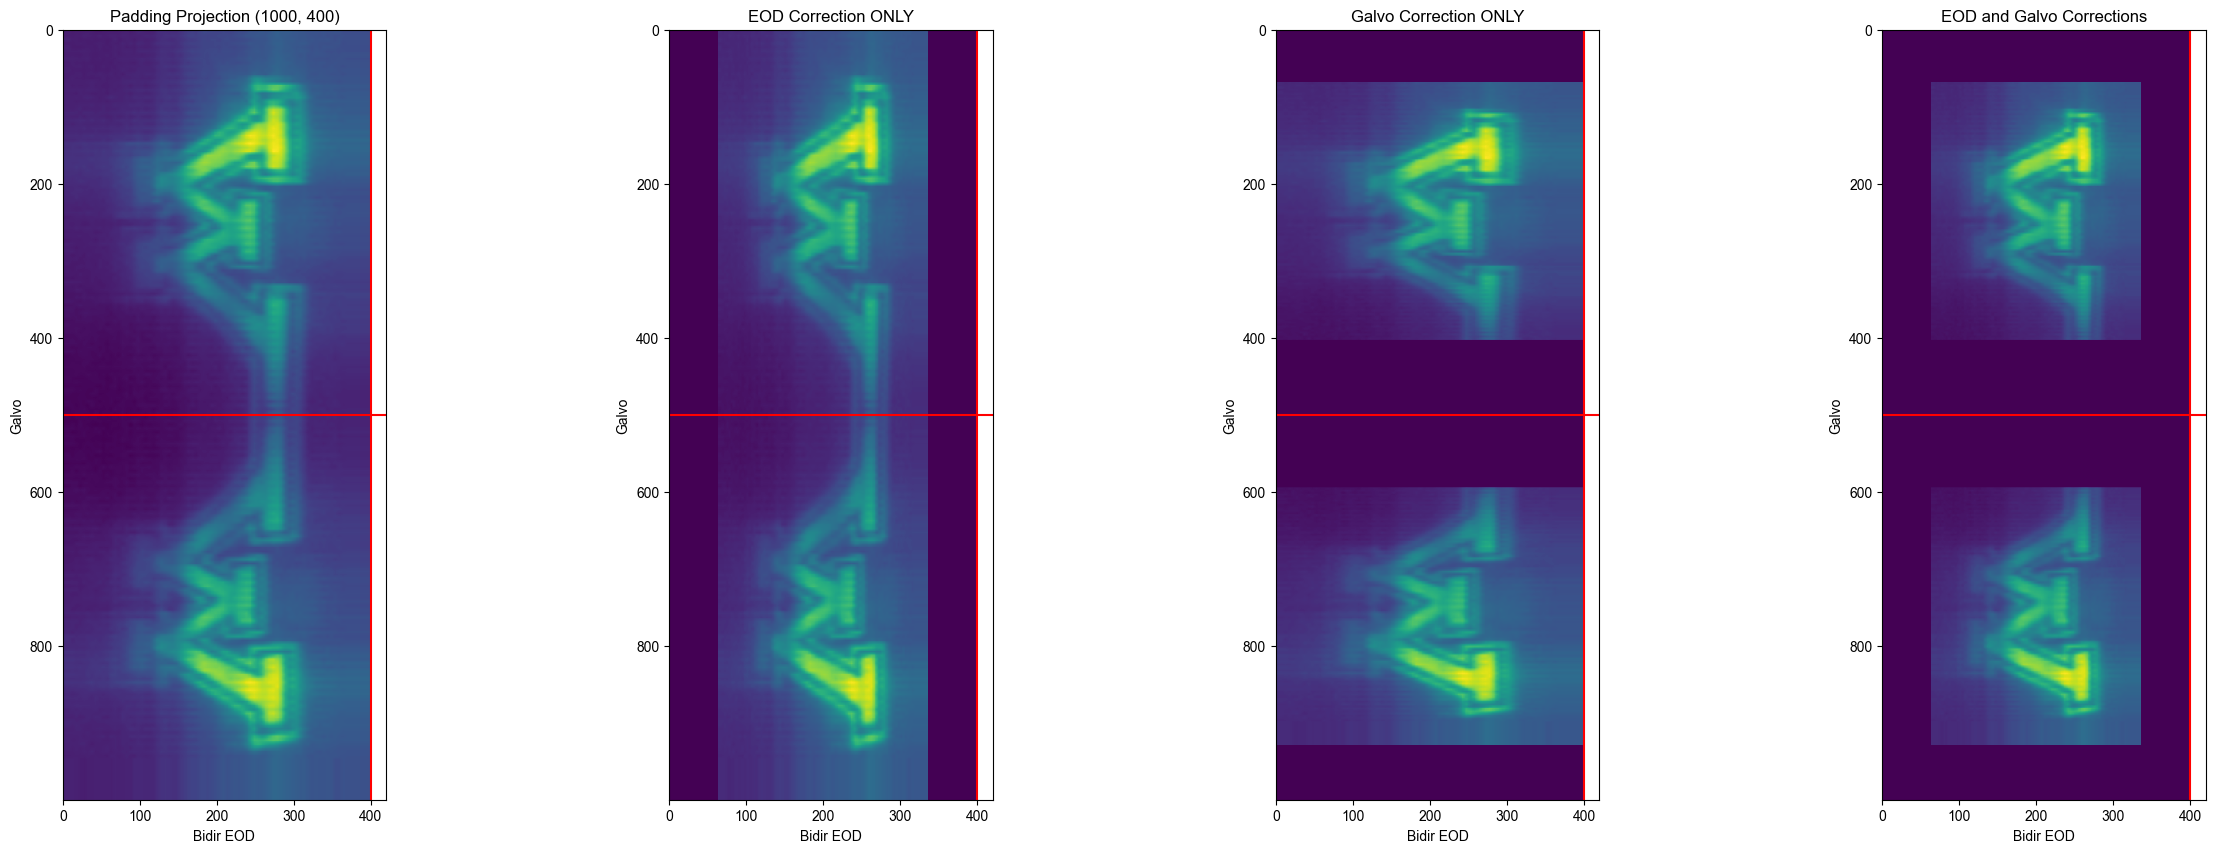

In [15]:
# data_EOD_Shifted_pad_Up_EODCorr = np.ones_like(data_EOD_Shifted_pad)*np.nan
data_EOD_Shifted_pad_Up_EODCorr = np.zeros_like(data_EOD_Shifted_pad_Up)
for t in range(data_EOD_Shifted_pad_Up.shape[0]):
    # data_EOD_Shifted_pad_Up_EODCorr[t,:,0:EOD_bidir_turn_px] = cv2.remap(data_EOD_Shifted_pad[t,:,0:EOD_bidir_turn_px], EOD_correction_map_x[:,0:EOD_bidir_turn_px], EOD_orig_map_y[:,0:EOD_bidir_turn_px], EOD_interpolation)
    # data_EOD_Shifted_pad_Up_EODCorr[t,:,EOD_bidir_turn_px:data_EOD_Shifted_pad_Up.shape[2]] = cv2.remap(data_EOD_Shifted_pad[t,:,EOD_bidir_turn_px:data_EOD_Shifted_pad_Up.shape[2]], EOD_correction_map_x[:,EOD_bidir_turn_px:data_EOD_Shifted_pad_Up.shape[2]], EOD_orig_map_y[:,EOD_bidir_turn_px:data_EOD_Shifted_pad_Up.shape[2]], EOD_interpolation)
    # data_EOD_Shifted_pad_Up_EODCorr[t,:,:] = cv2.remap(data_EOD_Shifted_pad[t,:,:], EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation)
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_Up[t,:,:])
    # tempImg[:,EOD_bidir_turn_px-1:data_EOD_Shifted_pad_Up.shape[2]] = 0
    tempImg = cv2.remap(tempImg, EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation)
    # tempImg[:,EOD_bidir_turn_px-1:data_EOD_Shifted_pad_Up.shape[2]] = 0
    data_EOD_Shifted_pad_Up_EODCorr[t,:,:] = data_EOD_Shifted_pad_Up_EODCorr[t,:,:] + tempImg
    # tempImg = copy.deepcopy(data_EOD_Shifted_pad[t,:,:])
    # # tempImg[:,0:EOD_bidir_turn_px] = 0
    # tempImg = cv2.remap(tempImg, EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation)
    # # tempImg[:,0:EOD_bidir_turn_px] = 0
    # data_EOD_Shifted_pad_Up_EODCorr[t,:,:] = data_EOD_Shifted_pad_Up_EODCorr[t,:,:] + tempImg
data_EOD_Shifted_pad_Up_EODCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_Up_EODCorr,axis=0)
##############################################################
data_EOD_Shifted_pad_Up_GalvoCorr = np.zeros_like(data_EOD_Shifted_pad_Up)
for t in range(data_EOD_Shifted_pad_Up.shape[0]):
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_Up[t,:,:])
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad_Up.shape[1],:] = 0
    tempImg = cv2.remap(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad_Up.shape[1],:] = 0
    data_EOD_Shifted_pad_Up_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_Up_GalvoCorr[t,:,:] + tempImg
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_Up[t,:,:])
    tempImg[0:galvo_bidir_turn_px,:] = 0
    tempImg = cv2.remap(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg[0:galvo_bidir_turn_px,:] = 0
    data_EOD_Shifted_pad_Up_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_Up_GalvoCorr[t,:,:] + tempImg
data_EOD_Shifted_pad_Up_GalvoCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_Up_GalvoCorr,axis=0)
##############################################################
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr = np.zeros_like(data_EOD_Shifted_pad_Up)
for t in range(data_EOD_Shifted_pad_Up.shape[0]):
    # data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[t,:,:] = cv2.remap(data_EOD_Shifted_pad_Up_EODCorr[t,:,:], galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    # data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[t,:,:] = cv2.remap(data_EOD_Shifted_pad_Up_EODCorr[t,:,:], galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_Up_EODCorr[t,:,:])
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad_Up.shape[1],:] = 0
    tempImg = cv2.remap(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad_Up.shape[1],:] = 0
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[t,:,:] + tempImg
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_Up_EODCorr[t,:,:])
    tempImg[0:galvo_bidir_turn_px,:] = 0
    tempImg = cv2.remap(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg[0:galvo_bidir_turn_px,:] = 0
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[t,:,:] + tempImg  
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr,axis=0)
##############################################################
fig,ax = plt.subplots(1,4,figsize = (30,10))
ax[0].imshow(data_EOD_Shifted_pad_Up_meanProj,interpolation='none')
ax[0].set_ylabel("Galvo")
ax[0].set_xlabel("Bidir EOD")
ax[0].set_title("Padding Projection "+str(data_EOD_Shifted_pad_Up_meanProj.shape))
ax[0].axvline(EOD_bidir_turn_px,color ='r')
ax[0].axhline(galvo_bidir_turn_px,color ='r')
ax[1].imshow(data_EOD_Shifted_pad_Up_EODCorr_meanProj,interpolation='none')
ax[1].set_ylabel("Galvo")
ax[1].set_xlabel("Bidir EOD")
ax[1].set_title("EOD Correction ONLY")
ax[1].axvline(EOD_bidir_turn_px,color ='r')
ax[1].axhline(galvo_bidir_turn_px,color ='r')
ax[2].imshow(data_EOD_Shifted_pad_Up_GalvoCorr_meanProj,interpolation='none')
ax[2].set_ylabel("Galvo")
ax[2].set_xlabel("Bidir EOD")
ax[2].set_title("Galvo Correction ONLY")
ax[2].axvline(EOD_bidir_turn_px,color ='r')
ax[2].axhline(galvo_bidir_turn_px,color ='r')
ax[3].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj,interpolation='none')
ax[3].set_ylabel("Galvo")
ax[3].set_xlabel("Bidir EOD")
ax[3].set_title("EOD and Galvo Corrections")
ax[3].axvline(EOD_bidir_turn_px,color ='r')
ax[3].axhline(galvo_bidir_turn_px,color ='r')

# <font size="5">Aaron correction

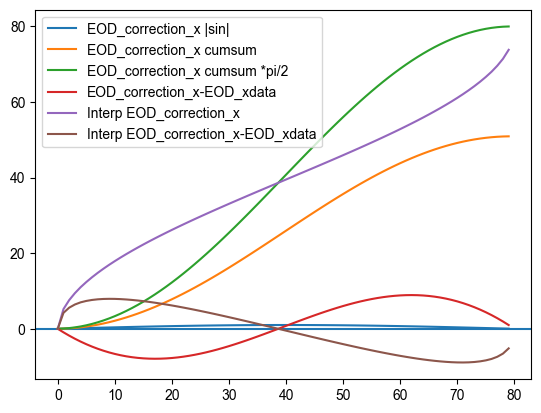

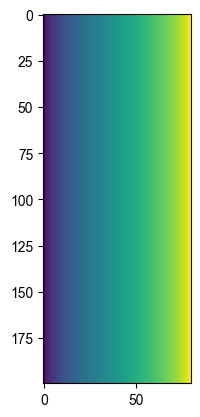

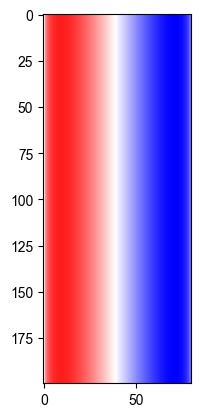

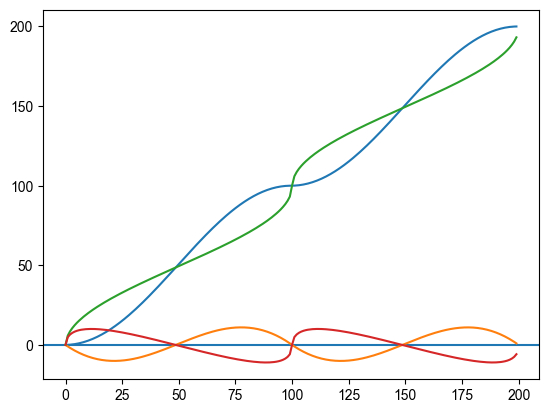

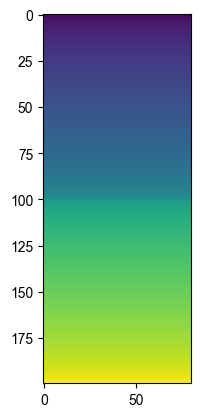

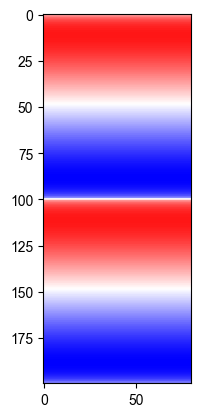

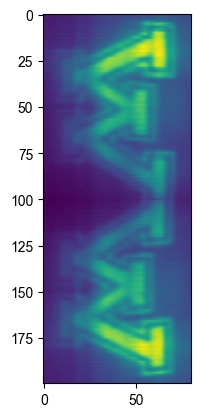

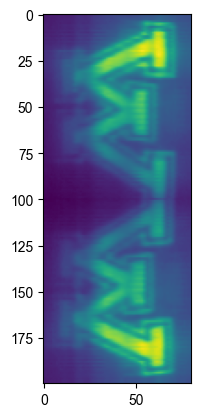

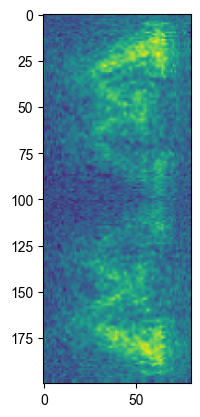

In [22]:
import scipy
import skimage

#really only two params to play with after missing lines added
EOD_correction_phase_shift_px = 0
galvo_correction_phase_shift_px = 0
galvo_bidir_turn_px = 100
##

#really shouldn't change
EOD_correction_freq = 0.5 
galvo_correction_freq = 1
##

EOD_xdata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[1])
h, w = data_EOD_Shifted_pad_meanProj.shape[:2]
EOD_orig_map_x, EOD_orig_map_y = np.meshgrid(np.arange(w), np.arange(h))
EOD_correction_phase_shift = (EOD_correction_phase_shift_px/w)* 2 * np.pi * EOD_correction_freq
x1_norm = ((EOD_orig_map_x) / (w)) * 2 * np.pi * EOD_correction_freq
plt.figure()
plt.axhline(0)
EOD_correction_x = np.abs(np.sin(x1_norm[0,:]-EOD_correction_phase_shift))
plt.plot(EOD_correction_x,label='EOD_correction_x |sin|')
EOD_correction_x = np.cumsum(EOD_correction_x)
plt.plot(EOD_correction_x,label='EOD_correction_x cumsum')
EOD_correction_x = EOD_correction_x*np.pi/2
plt.plot(EOD_correction_x,label='EOD_correction_x cumsum *pi/2')
plt.plot(EOD_correction_x-EOD_xdata,label='EOD_correction_x-EOD_xdata')
EOD_correction_x = scipy.interpolate.interp1d(EOD_correction_x,EOD_orig_map_x[0,:],
                                                  kind='linear',fill_value='extrapolate')(EOD_orig_map_x[0,:])
plt.plot(EOD_correction_x,label='Interp EOD_correction_x')
plt.plot(EOD_correction_x-EOD_xdata,label='Interp EOD_correction_x-EOD_xdata')
EOD_correction_map_x = np.repeat(EOD_correction_x,h).reshape(h,w,order='F')
plt.legend()
plt.figure()
plt.imshow(EOD_correction_map_x)

maxDelta = np.nanmax(np.abs(EOD_correction_map_x-EOD_orig_map_x))

plt.figure()
plt.imshow(EOD_correction_map_x-EOD_orig_map_x,cmap='bwr',vmin = -maxDelta, vmax = maxDelta)

galvo_ydata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[0])
galvo_rel_ydata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[0])-galvo_bidir_turn_px
h, w = data_EOD_Shifted_pad_meanProj.shape[:2]
galvo_orig_map_x, galvo_orig_map_y = np.meshgrid(np.arange(w), np.arange(h))
galvo_correction_phase_shift = (galvo_correction_phase_shift_px/h)* 2 * np.pi * galvo_correction_freq
y1_norm = ((galvo_orig_map_y) / (h)) * 2 * np.pi * galvo_correction_freq
galvo_correction_y = np.cumsum(np.abs(np.sin(y1_norm[:,0]-galvo_correction_phase_shift)),axis=0)*np.pi/2
plt.figure()
plt.axhline(0)
plt.plot(galvo_correction_y,label='galvo_correction_y')
plt.plot(galvo_correction_y-galvo_ydata,label='galvo_correction_y-galvo_ydata')
galvo_correction_y = scipy.interpolate.interp1d(galvo_correction_y,galvo_orig_map_y[:,0],
                                                  kind='linear',fill_value='extrapolate')(galvo_orig_map_y[:,0])
plt.plot(galvo_correction_y)
plt.plot(galvo_correction_y-galvo_ydata)
galvo_correction_map_y = np.repeat(galvo_correction_y,w).reshape(w,h,order='F').T
plt.figure()
plt.imshow(galvo_correction_map_y)

maxDelta = np.nanmax(np.abs(galvo_correction_map_y-galvo_orig_map_y))
plt.figure()
plt.imshow(galvo_correction_map_y-galvo_orig_map_y,cmap='bwr',vmin = -maxDelta, vmax = maxDelta)


tmap=np.dstack([galvo_correction_map_y, EOD_correction_map_x]).transpose([2,0,1])
data_EOD_Shifted_pad_meanProj_fullCorr = skimage.transform.warp(data_EOD_Shifted_pad_meanProj, tmap)

data_EOD_Shifted_pad_fullCorr = np.zeros_like(data_EOD_Shifted_pad)
for t in range(data_EOD_Shifted_pad.shape[0]):
    data_EOD_Shifted_pad_fullCorr[t,:,:] = skimage.transform.warp(data_EOD_Shifted_pad[t,:,:], tmap)
data_EOD_Shifted_pad_fullCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_fullCorr,axis=0)


plt.figure()
plt.imshow(data_EOD_Shifted_pad_meanProj_fullCorr)
plt.figure()
plt.imshow(data_EOD_Shifted_pad_fullCorr_meanProj)
plt.figure()
plt.imshow(data_EOD_Shifted_pad_fullCorr[t,:,:])


# <font size="5">Cropping

(79, 101)


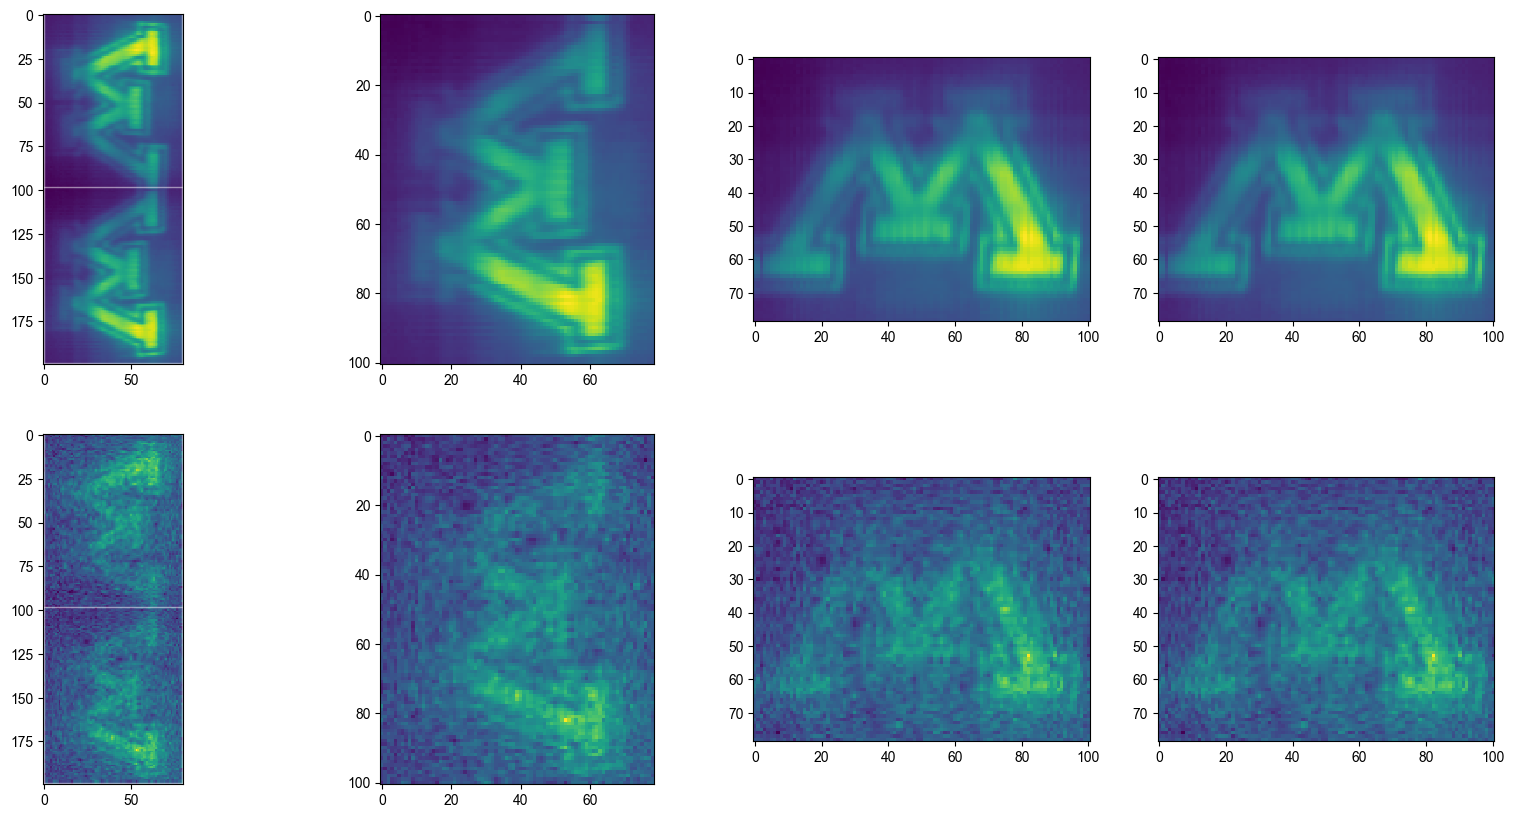

In [36]:
rotateAngle = -90

final_crop_x = [0,79]
final_crop_y = [98,199]
final_horz_scalar = 1
final_vert_scalar = 1

data_EOD_Shifted_pad_fullCorr_meanProj_crop = \
    data_EOD_Shifted_pad_fullCorr_meanProj[final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_pad_fullCorr_meanProj_crop[np.isnan(data_EOD_Shifted_pad_fullCorr_meanProj_crop)] = 0

data_EOD_Shifted_pad_fullCorr_crop = \
    data_EOD_Shifted_pad_fullCorr[:,final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_pad_fullCorr_crop[np.isnan(data_EOD_Shifted_pad_fullCorr_crop)] = 0

data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient = \
    np.fliplr(rotate(data_EOD_Shifted_pad_fullCorr_meanProj_crop,rotateAngle,axes = (0,1)))
data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient_resize = \
    cv2.resize(data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient, (0,0), fx=final_horz_scalar, fy=final_vert_scalar)
print(data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient_resize.shape)
data_EOD_Shifted_pad_fullCorr_crop_reorient = \
    np.ones((data_EOD_Shifted_pad_fullCorr.shape[0],\
    data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient.shape[0],\
    data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient.shape[1]))*np.nan
data_EOD_Shifted_pad_fullCorr_crop_reorient_resize = \
    np.ones((data_EOD_Shifted_pad_fullCorr.shape[0],\
    data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient_resize.shape[0],\
    data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient_resize.shape[1]))*np.nan
for t in range(data_EOD_Shifted_pad_fullCorr.shape[0]):
    data_EOD_Shifted_pad_fullCorr_crop_reorient[t,:,:] = \
        np.fliplr(rotate(data_EOD_Shifted_pad_fullCorr_crop[t,:,:],rotateAngle,axes = (0,1)))
    data_EOD_Shifted_pad_fullCorr_crop_reorient_resize[t,:,:] = \
        cv2.resize(data_EOD_Shifted_pad_fullCorr_crop_reorient[t,:,:], (0,0), fx=final_horz_scalar, fy=final_vert_scalar)

t = 0
fig,ax = plt.subplots(2,4,figsize = (20,10))
row = 0
im = ax[row,0].imshow(data_EOD_Shifted_pad_fullCorr_meanProj,interpolation='none')
ax[row,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[row,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[row,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[row,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[row,1].imshow(data_EOD_Shifted_pad_fullCorr_meanProj_crop,interpolation='none')
im = ax[row,2].imshow(data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient,interpolation='none')
im = ax[row,3].imshow(data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient_resize,interpolation='none')
row = 1
im = ax[row,0].imshow(data_EOD_Shifted_pad_fullCorr[t,:,:],interpolation='none')
ax[row,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[row,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[row,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[row,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[row,1].imshow(data_EOD_Shifted_pad_fullCorr_crop[t,:,:],interpolation='none')
im = ax[row,2].imshow(data_EOD_Shifted_pad_fullCorr_crop_reorient[t,:,:],interpolation='none')
im = ax[row,3].imshow(data_EOD_Shifted_pad_fullCorr_crop_reorient_resize[t,:,:],interpolation='none')


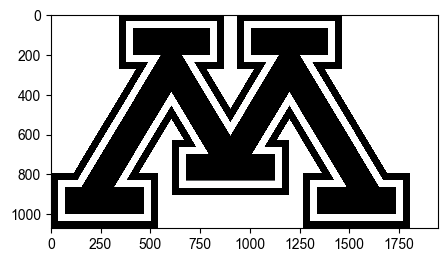

In [4]:
refImg = Image.open(os.path.join(filePath,refImgFile))
plt.figure(figsize = (5,5))
plt.imshow(refImg,interpolation='none')

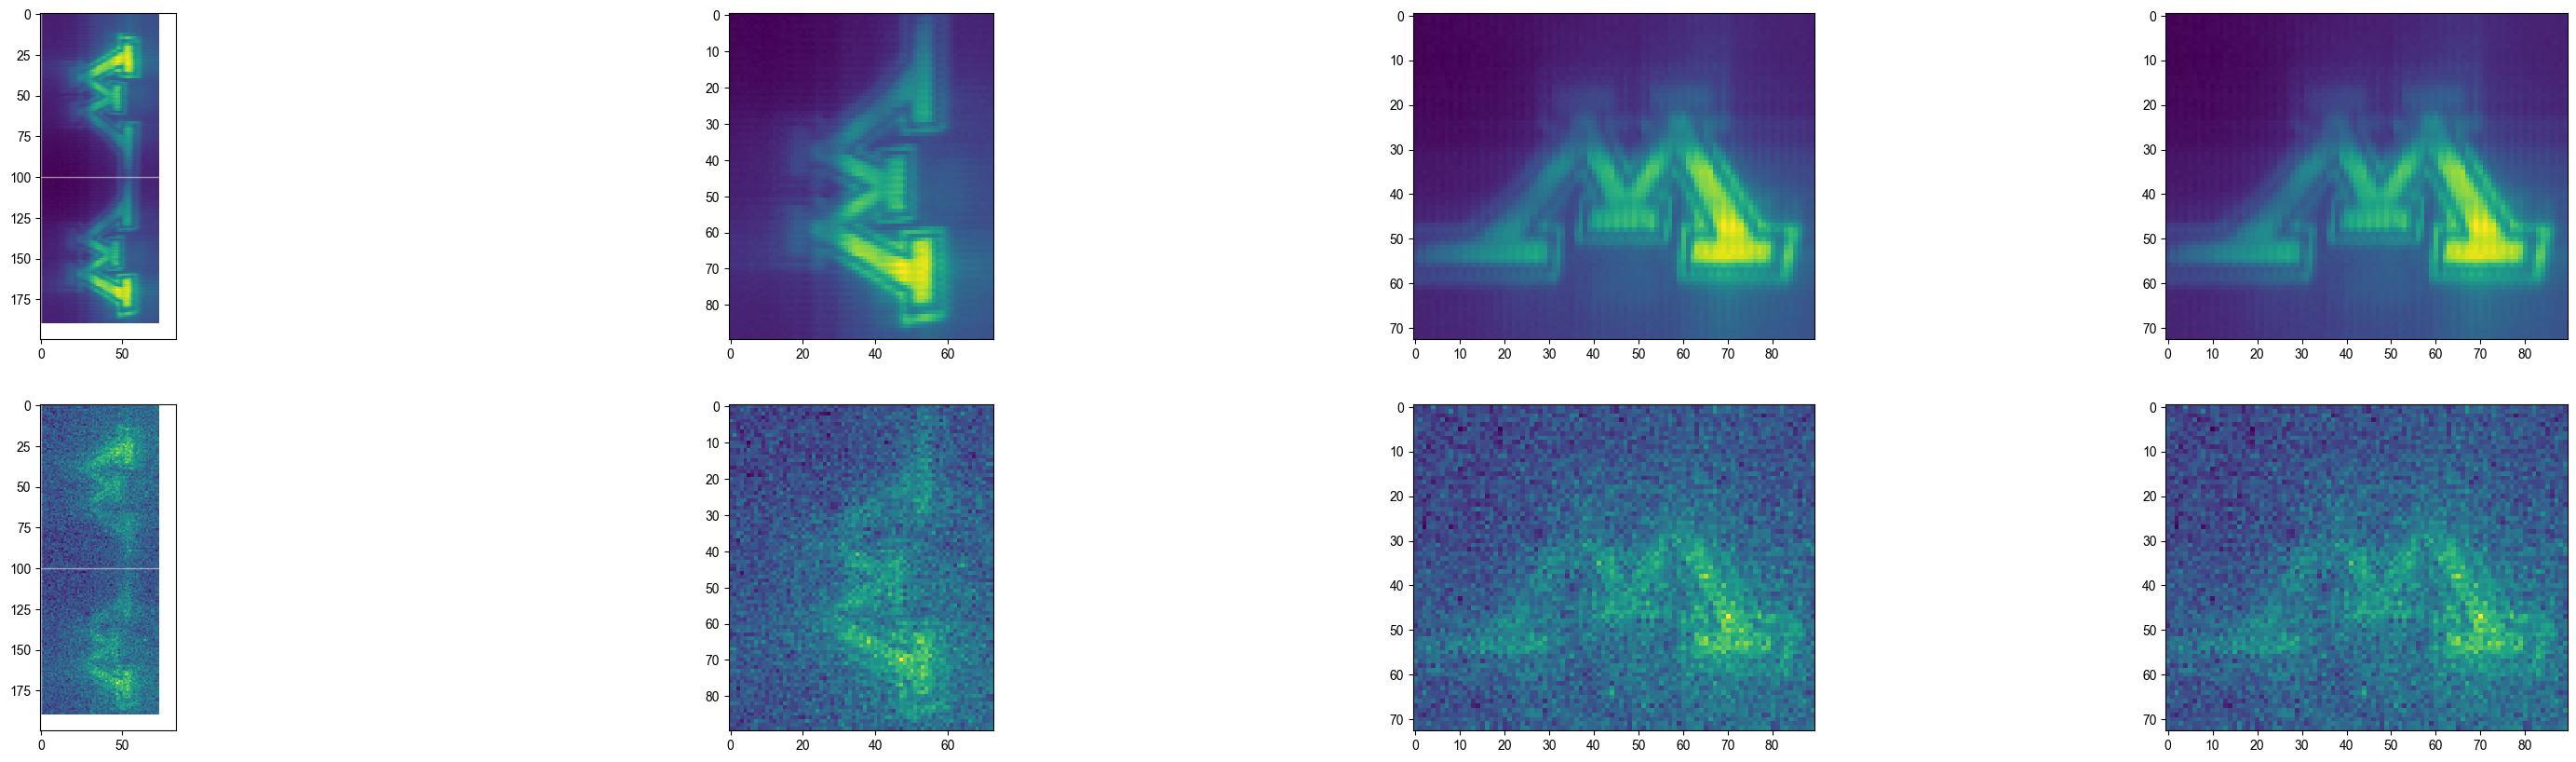

In [37]:
rotateAngle = -90

final_crop_x = [0,79]
final_crop_y = [100,190]
final_horz_scalar = 1
final_vert_scalar = 1

data_EOD_Shifted_meanProj_crop = \
    data_EOD_Shifted_meanProj[final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_meanProj_crop[np.isnan(data_EOD_Shifted_meanProj_crop)] = 0
data_EOD_Shifted_meanProj_crop_reorient = \
    np.fliplr(rotate(data_EOD_Shifted_meanProj_crop,rotateAngle,axes = (0,1)))
data_EOD_Shifted_meanProj_crop_reorient_resize = \
    cv2.resize(data_EOD_Shifted_meanProj_crop_reorient, (0,0), fx=final_horz_scalar, fy=final_vert_scalar)
data_EOD_Shifted_crop = data_EOD_Shifted[:,final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_crop[np.isnan(data_EOD_Shifted_crop)] = 0
data_EOD_Shifted_crop_reorient = \
    np.ones((data_EOD_Shifted_pad.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient.shape[1]))*np.nan
data_EOD_Shifted_crop_reorient_resize = \
    np.ones((data_EOD_Shifted_pad.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient_resize.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient_resize.shape[1]))*np.nan
for t in range(data_EOD_Shifted.shape[0]):
    data_EOD_Shifted_crop_reorient[t,:,:] = \
        np.fliplr(rotate(data_EOD_Shifted_crop[t,:,:],rotateAngle,axes = (0,1)))
    data_EOD_Shifted_crop_reorient_resize[t,:,:] = \
        cv2.resize(data_EOD_Shifted_crop_reorient[t,:,:], (0,0), fx=final_horz_scalar, fy=final_vert_scalar)
t = 0
fig,ax = plt.subplots(2,4,figsize = (40,10))
im = ax[0,0].imshow(data_EOD_Shifted_meanProj,interpolation='none')
ax[0,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[0,1].imshow(data_EOD_Shifted_meanProj_crop,interpolation='none')
im = ax[0,2].imshow(data_EOD_Shifted_meanProj_crop_reorient,interpolation='none')
im = ax[0,3].imshow(data_EOD_Shifted_meanProj_crop_reorient_resize,interpolation='none')
im = ax[1,0].imshow(data_EOD_Shifted[t,:,:],interpolation='none')
ax[1,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[1,1].imshow(data_EOD_Shifted_crop[t,:,:],interpolation='none')
im = ax[1,2].imshow(data_EOD_Shifted_crop_reorient[t,:,:],interpolation='none')
im = ax[1,3].imshow(data_EOD_Shifted_crop_reorient_resize[t,:,:],interpolation='none')


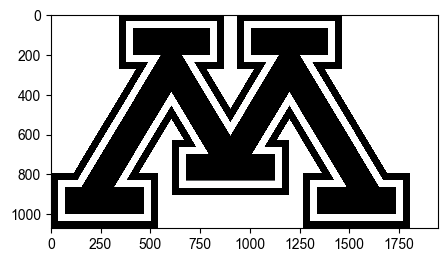

In [4]:
refImg = Image.open(os.path.join(filePath,refImgFile))
plt.figure(figsize = (5,5))
plt.imshow(refImg,interpolation='none')

In [31]:
def imshow_cleanup(ax):
    ax.axes.xaxis.set_visible(False)
    ax.axes.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_facecolor('none')
    return ax

%Saturated = 0.3
%Saturated = 0.2
%Saturated = 0.0


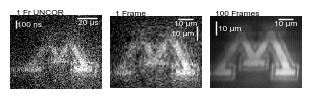

In [47]:
figDir = filePath
figName = "500kHz_M.pdf"

EO_scaling_ns = 12.5
Galvo_scaling_us = 1

y_ns = 100
yy_len_px = y_ns/EO_scaling_ns

x_us = 20
xx_len_px = x_us/Galvo_scaling_us


t = 0
y_um_px = 50/data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[1]
y_um = 10
y_len_px = y_um/y_um_px

x_um_px = 60/data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]
x_um = 10
x_len_px = x_um/x_um_px

figsize = (3,3)
# figsize = (10,10)
fontsize = 6
meanRange=list(range(0,100))
fig,ax=sled_general_tools.clean_subplots(1,3,figsize = figsize,constrained_layout=True)

col = 0
minVal = 0
maxVal = 100
img = copy.deepcopy(data_EOD_Shifted_crop_reorient_resize[t,:,:])
perSat = np.nansum(img>maxVal)/(img.shape[0]*img.shape[1])*100
print(f'%Saturated = {perSat:.1f}')
im = ax[col].imshow(img,\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')

#vert/EO
ax[col].plot([5,5],[5,5+yy_len_px],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[col].text(6,5+yy_len_px/2,str(y_ns)+' ns',color=(1,1,1),fontsize=fontsize,ha='left',va='center')

ax[col].plot([data_EOD_Shifted_crop_reorient_resize.shape[2]-5,data_EOD_Shifted_crop_reorient_resize.shape[2]-5-xx_len_px],[3,3],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[col].text(data_EOD_Shifted_crop_reorient_resize.shape[2]-5-x_len_px/2,4,str(x_us)+' μs',color=(1,1,1),fontsize=fontsize,ha='center',va='top')
ax[col].text(5,0,"1 Fr UNCOR",color=(0,0,0),fontsize=fontsize,ha='left',va='bottom')
ax[col]=imshow_cleanup(ax[col])


col = 1
minVal = 0
maxVal = 100
img = copy.deepcopy(data_EOD_Shifted_pad_fullCorr_crop_reorient[t,:,:])
perSat = np.nansum(img>maxVal)/(img.shape[0]*img.shape[1])*100
print(f'%Saturated = {perSat:.1f}')
im = ax[col].imshow(img,\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[col].plot([data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-6,data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-6],[10,10+y_len_px],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[col].text(data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-8,10+y_len_px/2,'10 μm',color=(1,1,1),fontsize=fontsize,ha='right',va='center')

ax[col].plot([data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-10,data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-10-x_len_px],[3,3],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[col].text(data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-10-x_len_px/2,4,'10 μm',color=(1,1,1),fontsize=fontsize,ha='center',va='top')
ax[col].text(5,0,"1 Frame",color=(0,0,0),fontsize=fontsize,ha='left',va='bottom')
ax[col]=imshow_cleanup(ax[col])

col = 2
minVal = 0
maxVal = 100
img = copy.deepcopy(np.nanmean(data_EOD_Shifted_pad_fullCorr_crop_reorient[meanRange,:,:],axis=0))
perSat = np.nansum(img>maxVal)/(img.shape[0]*img.shape[1])*100
# print(np.nansum(img>maxVal))
print(f'%Saturated = {perSat:.1f}')
im = ax[col].imshow(img,\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[col].plot([6,6],[5,5+y_len_px],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[col].text(8,5+y_len_px/2,'10 μm',color=(1,1,1),fontsize=fontsize,ha='left',va='center')

ax[col].plot([data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-10,data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-10-x_len_px],[3,3],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[col].text(data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-10-x_len_px/2,4,'10 μm',color=(1,1,1),fontsize=fontsize,ha='center',va='top')
ax[col].text(5,0,str(len(meanRange))+" Frames",color=(0,0,0),fontsize=fontsize,ha='left',va='bottom')
ax[col]=imshow_cleanup(ax[col])

plt.show()
with PdfPages(os.path.join(figDir,figName)) as pdf:
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


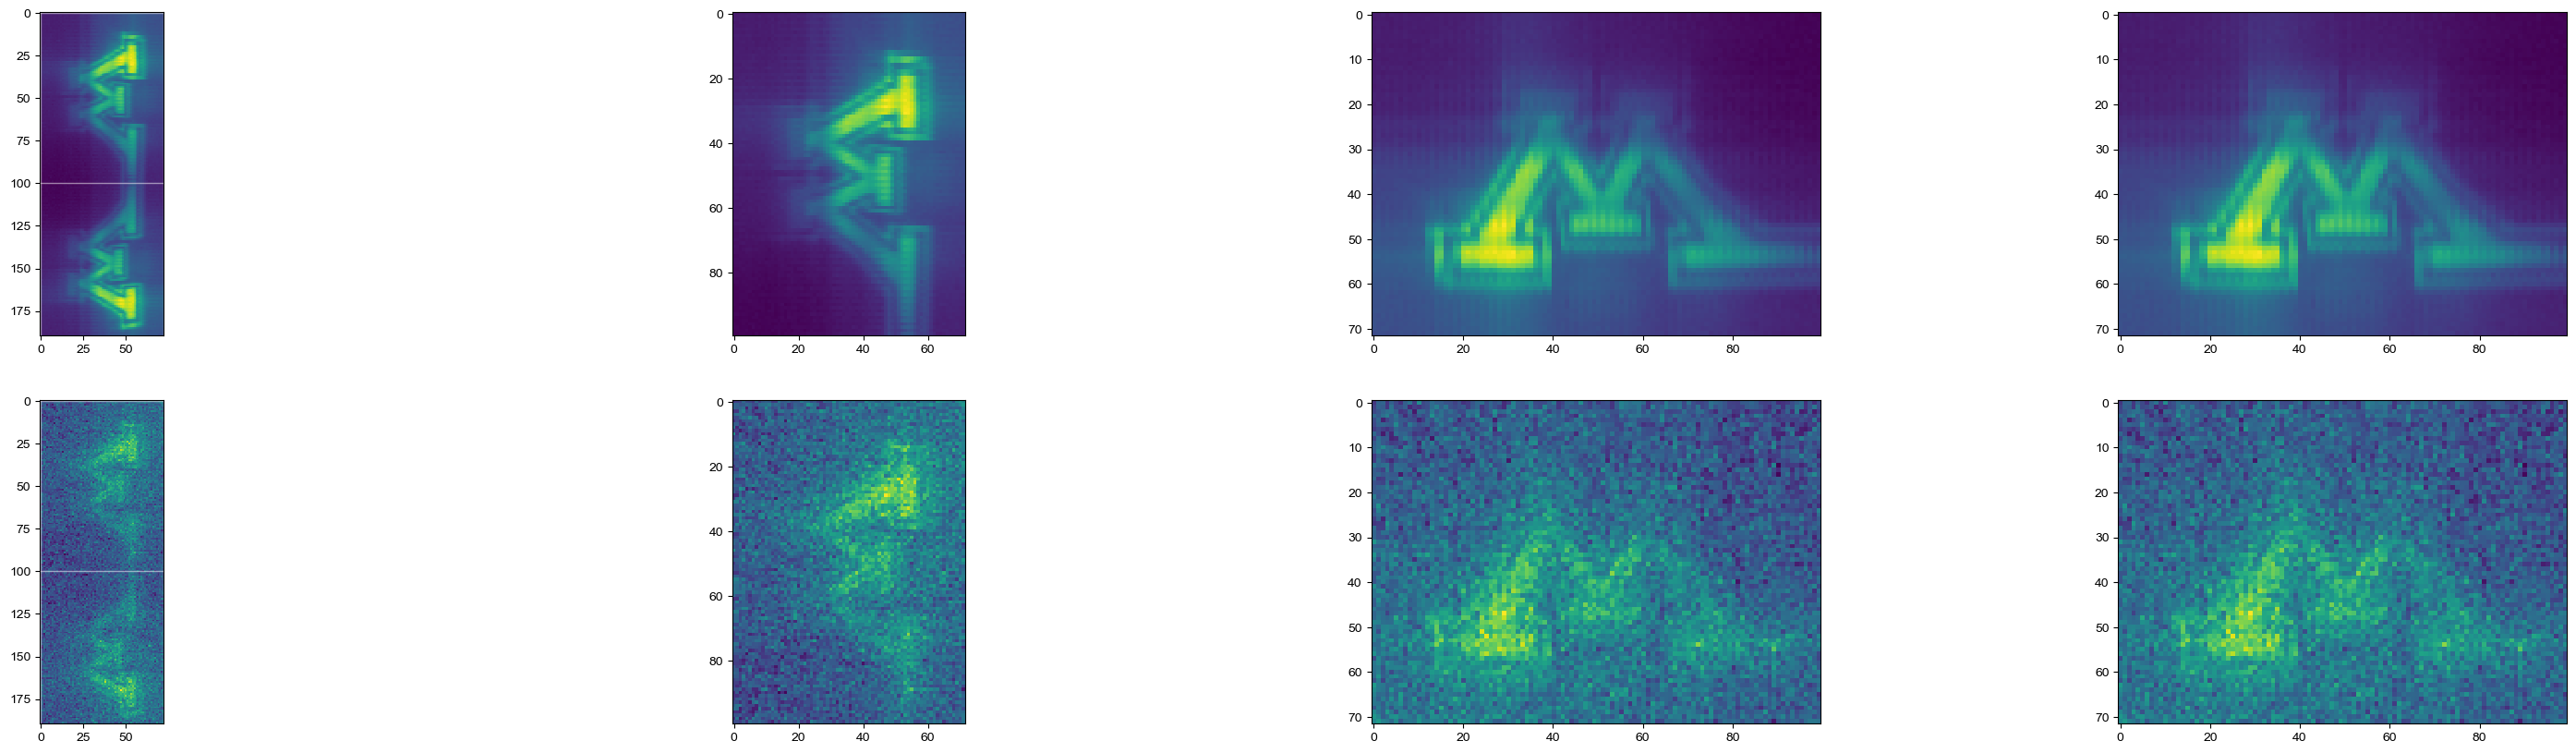

In [22]:
rotateAngle = -90

final_crop_x = [0,72]
final_crop_y = [0,100]
final_horz_scalar = 1
final_vert_scalar = 1

data_EOD_Shifted_meanProj_crop = \
    data_EOD_Shifted_meanProj[final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_meanProj_crop[np.isnan(data_EOD_Shifted_meanProj_crop)] = 0
data_EOD_Shifted_meanProj_crop_reorient = \
    np.fliplr(rotate(data_EOD_Shifted_meanProj_crop,rotateAngle,axes = (0,1)))
data_EOD_Shifted_meanProj_crop_reorient_resize = \
    cv2.resize(data_EOD_Shifted_meanProj_crop_reorient, (0,0), fx=final_horz_scalar, fy=final_vert_scalar)
data_EOD_Shifted_crop = data_EOD_Shifted[:,final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_crop[np.isnan(data_EOD_Shifted_crop)] = 0
data_EOD_Shifted_crop_reorient = \
    np.ones((data_EOD_Shifted_pad.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient.shape[1]))*np.nan
data_EOD_Shifted_crop_reorient_resize = \
    np.ones((data_EOD_Shifted_pad.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient_resize.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient_resize.shape[1]))*np.nan
for t in range(data_EOD_Shifted.shape[0]):
    data_EOD_Shifted_crop_reorient[t,:,:] = \
        np.fliplr(rotate(data_EOD_Shifted_crop[t,:,:],rotateAngle,axes = (0,1)))
    data_EOD_Shifted_crop_reorient_resize[t,:,:] = \
        cv2.resize(data_EOD_Shifted_crop_reorient[t,:,:], (0,0), fx=final_horz_scalar, fy=final_vert_scalar)

t = 0
fig,ax = plt.subplots(2,4,figsize = (40,10))
im = ax[0,0].imshow(data_EOD_Shifted_meanProj,interpolation='none')
ax[0,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[0,1].imshow(data_EOD_Shifted_meanProj_crop,interpolation='none')
im = ax[0,2].imshow(data_EOD_Shifted_meanProj_crop_reorient,interpolation='none')
im = ax[0,3].imshow(data_EOD_Shifted_meanProj_crop_reorient_resize,interpolation='none')
im = ax[1,0].imshow(data_EOD_Shifted[t,:,:],interpolation='none')
ax[1,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[1,1].imshow(data_EOD_Shifted_crop[t,:,:],interpolation='none')
im = ax[1,2].imshow(data_EOD_Shifted_crop_reorient[t,:,:],interpolation='none')
im = ax[1,3].imshow(data_EOD_Shifted_crop_reorient_resize[t,:,:],interpolation='none')


# <font size="5">Bidir EOD Cropping

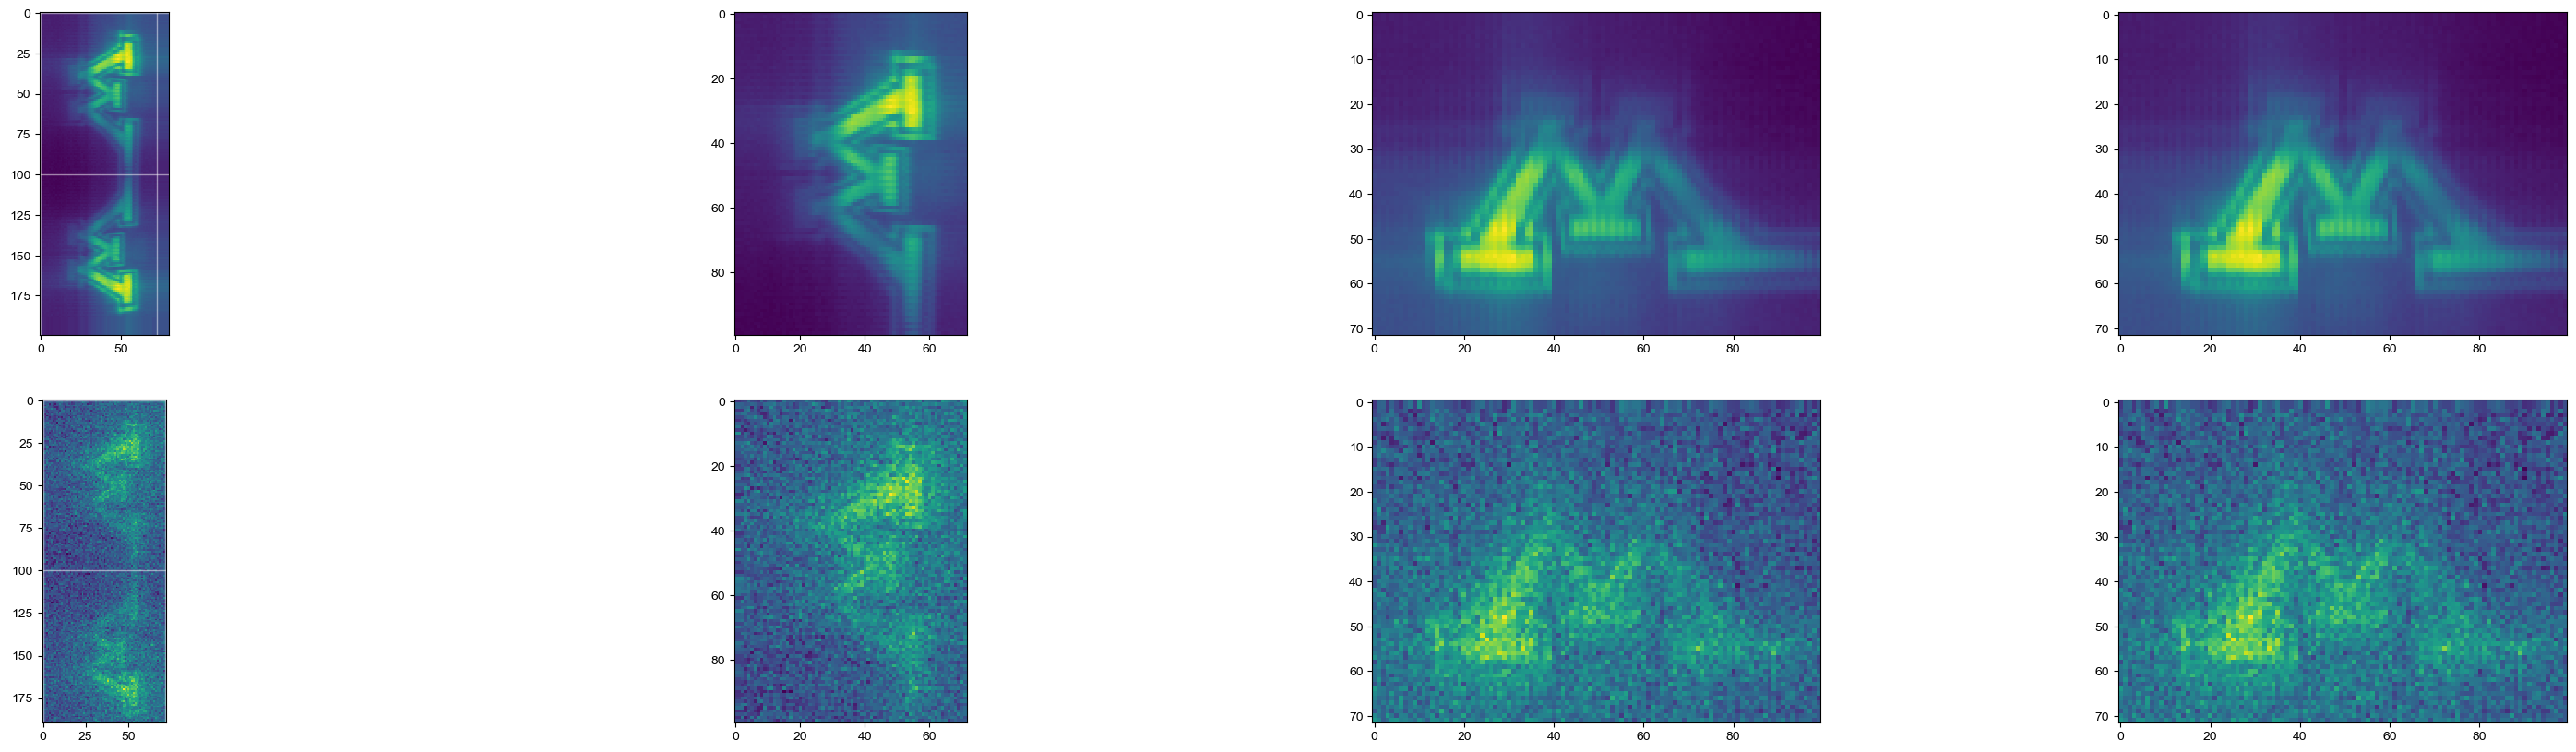

In [23]:
rotateAngle = -90

final_crop_x = [0,72]
final_crop_y = [0,100]
final_horz_scalar = 1
final_vert_scalar = 1

data_EOD_Shifted_pad_meanProj_crop = \
    data_EOD_Shifted_pad_meanProj[final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_pad_meanProj_crop[np.isnan(data_EOD_Shifted_pad_meanProj_crop)] = 0
data_EOD_Shifted_pad_meanProj_crop_reorient = \
    np.fliplr(rotate(data_EOD_Shifted_pad_meanProj_crop,rotateAngle,axes = (0,1)))
data_EOD_Shifted_pad_meanProj_crop_reorient_resize = \
    cv2.resize(data_EOD_Shifted_pad_meanProj_crop_reorient, (0,0), fx=final_horz_scalar, fy=final_vert_scalar)
data_EOD_Shifted_pad_crop = data_EOD_Shifted_pad[:,final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_pad_crop[np.isnan(data_EOD_Shifted_pad_crop)] = 0
data_EOD_Shifted_pad_crop_reorient = \
    np.ones((data_EOD_Shifted_pad.shape[0],\
    data_EOD_Shifted_pad_meanProj_crop_reorient.shape[0],\
    data_EOD_Shifted_pad_meanProj_crop_reorient.shape[1]))*np.nan
data_EOD_Shifted_pad_crop_reorient_resize = \
    np.ones((data_EOD_Shifted_pad.shape[0],\
    data_EOD_Shifted_pad_meanProj_crop_reorient_resize.shape[0],\
    data_EOD_Shifted_pad_meanProj_crop_reorient_resize.shape[1]))*np.nan
for t in range(data_EOD_Shifted_pad.shape[0]):
    data_EOD_Shifted_pad_crop_reorient[t,:,:] = \
        np.fliplr(rotate(data_EOD_Shifted_pad_crop[t,:,:],rotateAngle,axes = (0,1)))
    data_EOD_Shifted_pad_crop_reorient_resize[t,:,:] = \
        cv2.resize(data_EOD_Shifted_pad_crop_reorient[t,:,:], (0,0), fx=final_horz_scalar, fy=final_vert_scalar)

t = 0
fig,ax = plt.subplots(2,4,figsize = (40,10))
im = ax[0,0].imshow(data_EOD_Shifted_pad_meanProj,interpolation='none')
ax[0,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[0,1].imshow(data_EOD_Shifted_pad_meanProj_crop,interpolation='none')
im = ax[0,2].imshow(data_EOD_Shifted_pad_meanProj_crop_reorient,interpolation='none')
im = ax[0,3].imshow(data_EOD_Shifted_pad_meanProj_crop_reorient_resize,interpolation='none')
im = ax[1,0].imshow(data_EOD_Shifted[t,:,:],interpolation='none')
ax[1,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[1,1].imshow(data_EOD_Shifted_pad_crop[t,:,:],interpolation='none')
im = ax[1,2].imshow(data_EOD_Shifted_pad_crop_reorient[t,:,:],interpolation='none')
im = ax[1,3].imshow(data_EOD_Shifted_pad_crop_reorient_resize[t,:,:],interpolation='none')


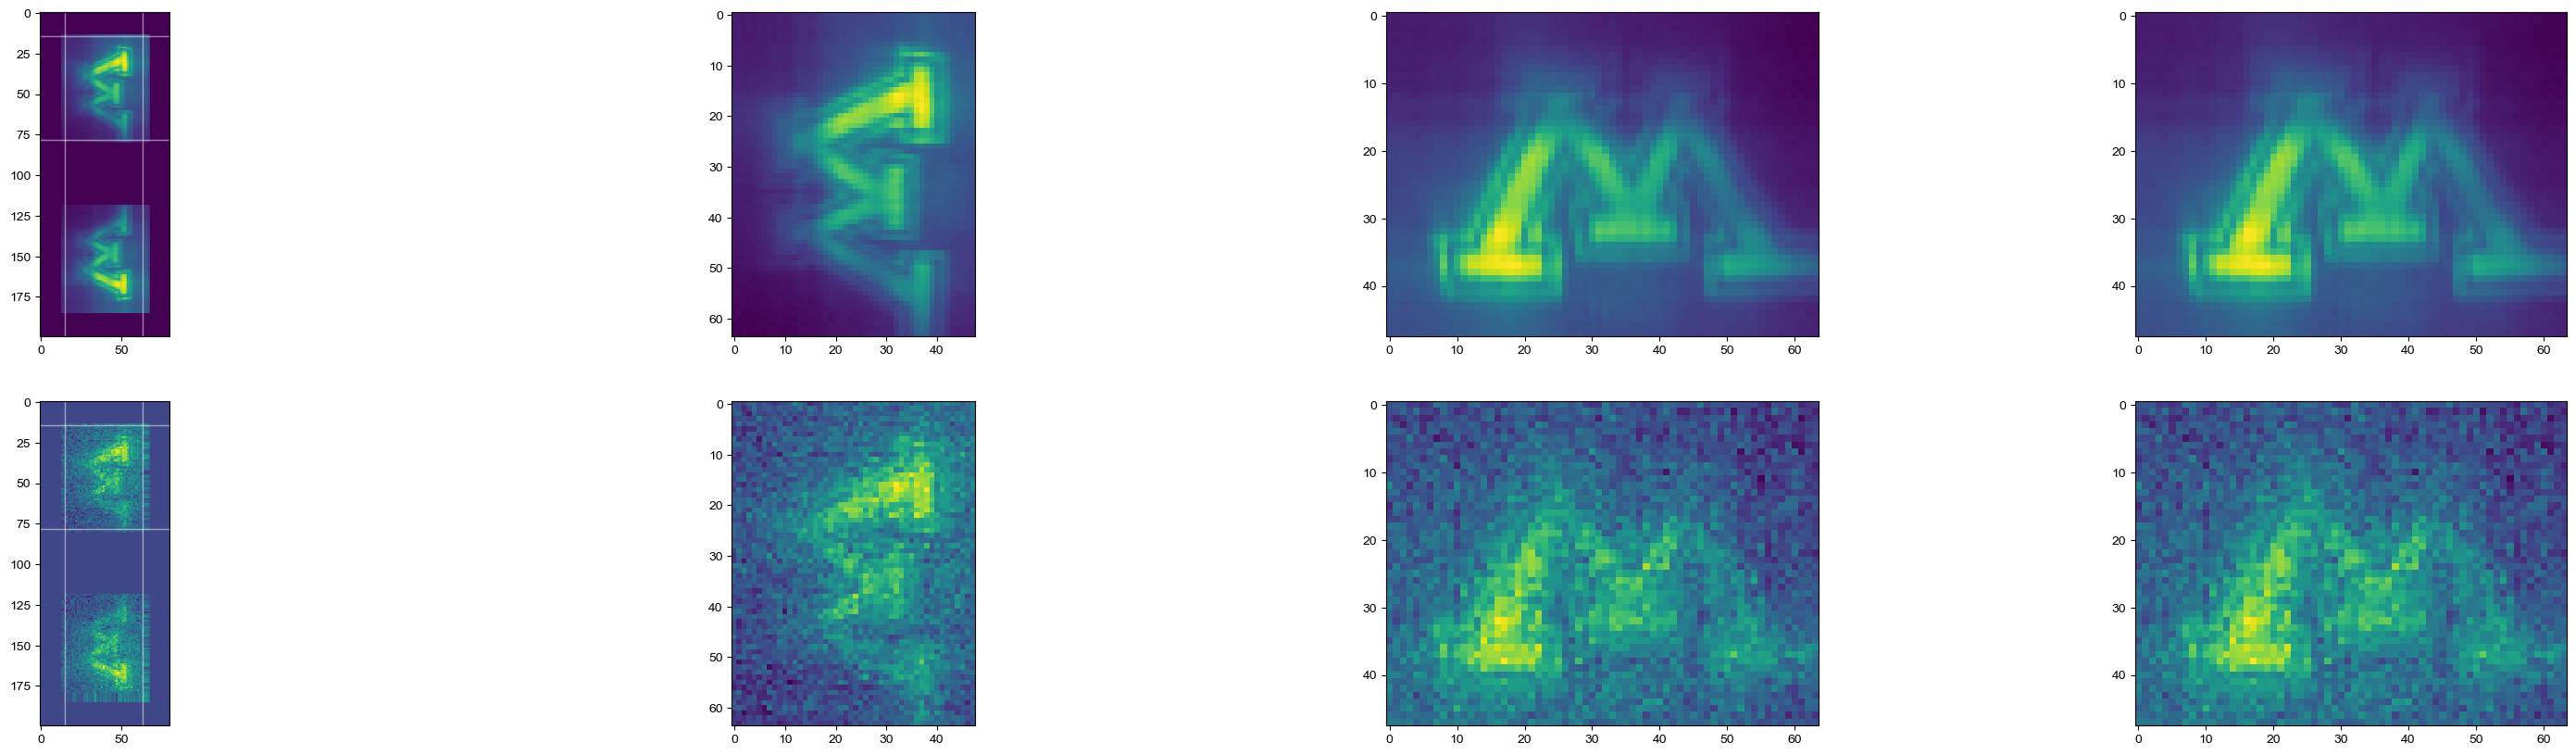

In [24]:
rotateAngle = -90

final_crop_x = [15,63]
final_crop_y = [14,78]
final_horz_scalar = 1
final_vert_scalar = 1

data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop = \
    data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj[final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop[np.isnan(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop)] = 0
data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient = \
    np.fliplr(rotate(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop,rotateAngle,axes = (0,1)))
data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient_resize = \
    cv2.resize(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient, (0,0), fx=final_horz_scalar, fy=final_vert_scalar)
data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop = data_EOD_Shifted_pad_EODCorr_GalvoCorr[:,final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop[np.isnan(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop)] = 0
data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient = \
    np.ones((data_EOD_Shifted_pad_EODCorr_GalvoCorr.shape[0],\
    data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient.shape[0],\
    data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient.shape[1]))*np.nan
data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient_resize = \
    np.ones((data_EOD_Shifted_pad_EODCorr_GalvoCorr.shape[0],\
    data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient_resize.shape[0],\
    data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient_resize.shape[1]))*np.nan
for t in range(data_EOD_Shifted_pad_EODCorr_GalvoCorr.shape[0]):
    data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient[t,:,:] = \
        np.fliplr(rotate(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop[t,:,:],rotateAngle,axes = (0,1)))
    data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient_resize[t,:,:] = \
        cv2.resize(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient[t,:,:], (0,0), fx=final_horz_scalar, fy=final_vert_scalar)

t = 0
fig,ax = plt.subplots(2,4,figsize = (40,10))
im = ax[0,0].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj,interpolation='none')
ax[0,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[0,1].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop,interpolation='none')
im = ax[0,2].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient,interpolation='none')
im = ax[0,3].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient_resize,interpolation='none')
im = ax[1,0].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:],interpolation='none')
ax[1,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[1,1].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop[t,:,:],interpolation='none')
im = ax[1,2].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient[t,:,:],interpolation='none')
im = ax[1,3].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient_resize[t,:,:],interpolation='none')


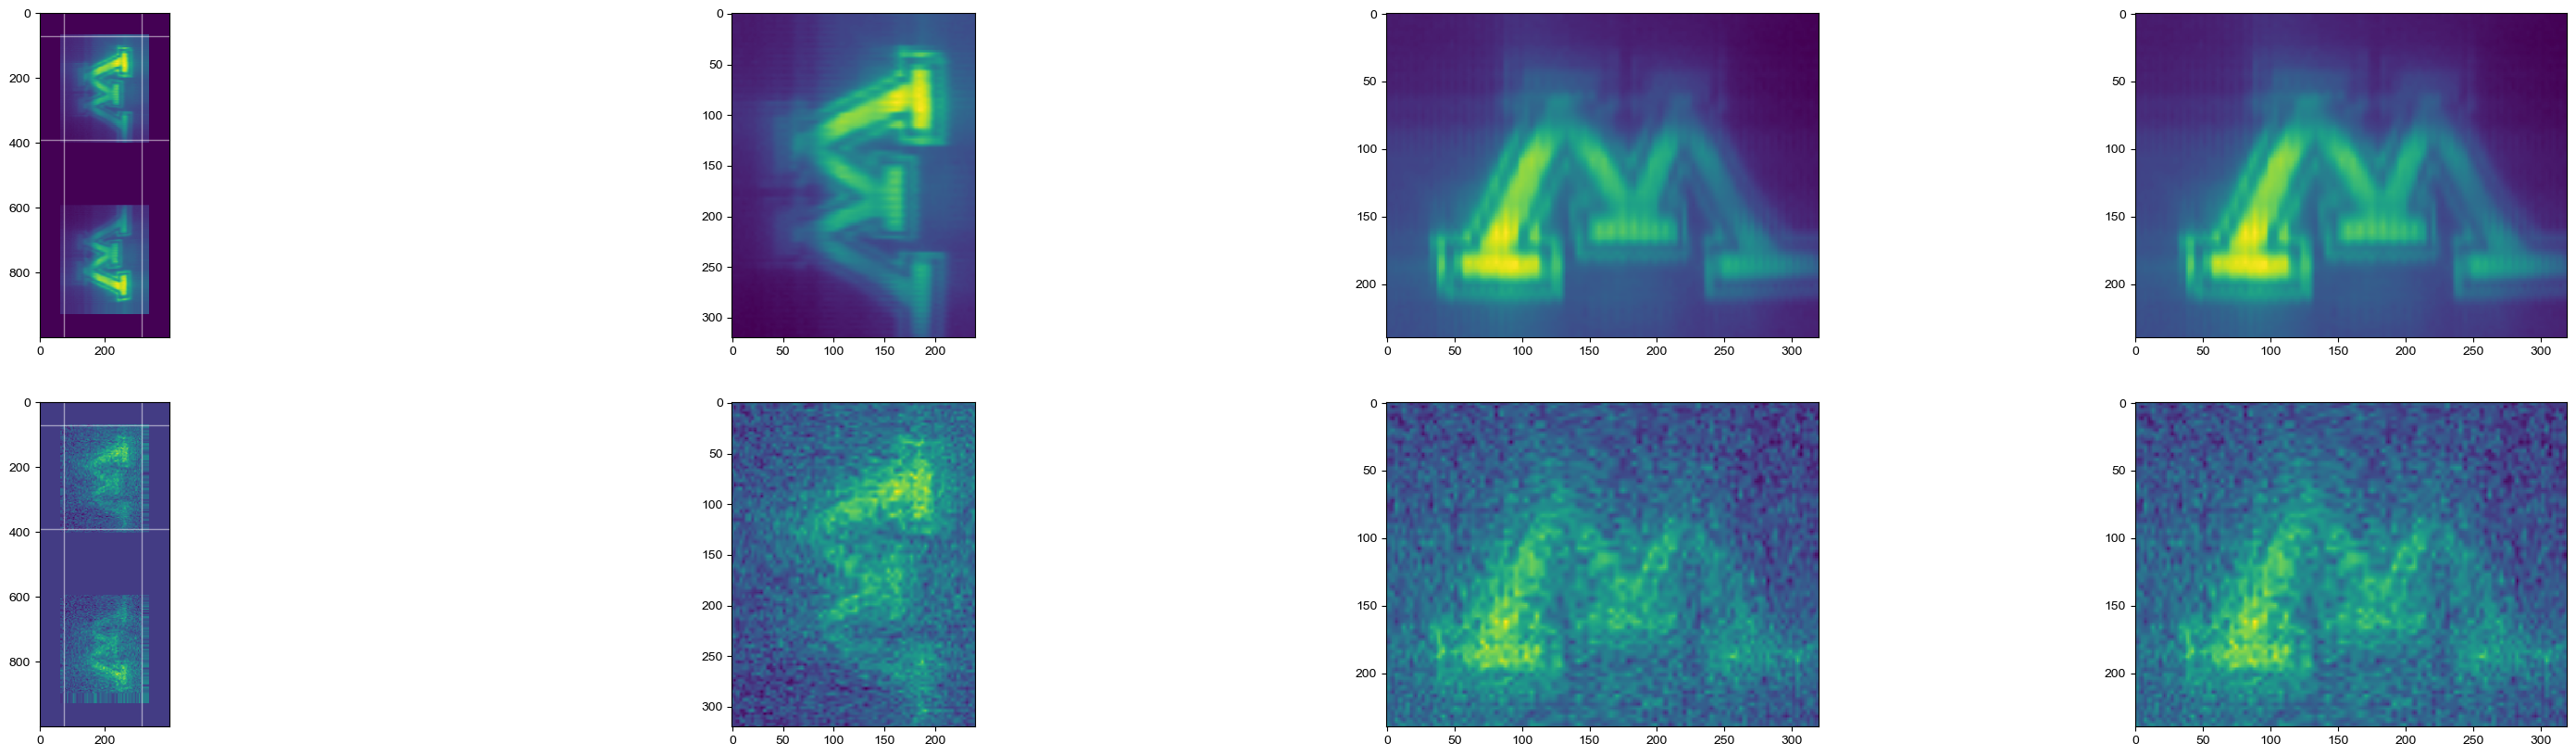

In [25]:
rotateAngle = -90

final_crop_x = [15*EOD_Upscale,63*EOD_Upscale]
final_crop_y = [14*Galvo_Upscale,78*Galvo_Upscale]
final_horz_scalar = 1
final_vert_scalar = 1

data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop = \
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj[final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop[np.isnan(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop)] = 0
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient = \
    np.fliplr(rotate(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop,rotateAngle,axes = (0,1)))
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient_resize = \
    cv2.resize(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient, (0,0), fx=final_horz_scalar, fy=final_vert_scalar)
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop = data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[:,final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop[np.isnan(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop)] = 0
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient = \
    np.ones((data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr.shape[0],\
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient.shape[0],\
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient.shape[1]))*np.nan
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient_resize = \
    np.ones((data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr.shape[0],\
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient_resize.shape[0],\
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient_resize.shape[1]))*np.nan
for t in range(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr.shape[0]):
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient[t,:,:] = \
        np.fliplr(rotate(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop[t,:,:],rotateAngle,axes = (0,1)))
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient_resize[t,:,:] = \
        cv2.resize(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient[t,:,:], (0,0), fx=final_horz_scalar, fy=final_vert_scalar)

t = 0
fig,ax = plt.subplots(2,4,figsize = (40,10))
im = ax[0,0].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj,interpolation='none')
ax[0,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[0,1].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop,interpolation='none')
im = ax[0,2].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient,interpolation='none')
im = ax[0,3].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient_resize,interpolation='none')
im = ax[1,0].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[t,:,:],interpolation='none')
ax[1,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[1,1].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop[t,:,:],interpolation='none')
im = ax[1,2].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient[t,:,:],interpolation='none')
im = ax[1,3].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient_resize[t,:,:],interpolation='none')


# <font size="5">Bidir EOD Figs

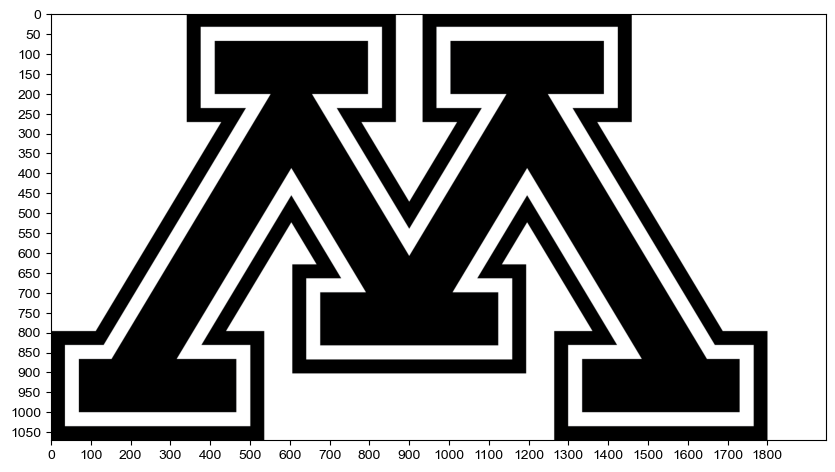

In [21]:
plt.figure(figsize=(10,10))
plt.imshow(refImg)
plt.yticks(np.arange(0,1100,50));
plt.xticks(np.arange(0,1900,100));

In [20]:
np.array(refImg).shape

(1071, 1947, 4)

In [21]:
1071-800

271

In [22]:
1947/1071

1.8179271708683473

In [23]:
1440/856.8

1.680672268907563

In [24]:
250/148.75

1.680672268907563

In [25]:
148.75/1071

0.1388888888888889

In [26]:
271*0.138

37.398

In [27]:
y_um_px = 148.75/856.8
print(f'y_um_px = {y_um_px}')
x_um_px = 250/1440
print(f'x_um_px = {x_um_px}')

y_um_px = 0.17361111111111113
x_um_px = 0.1736111111111111


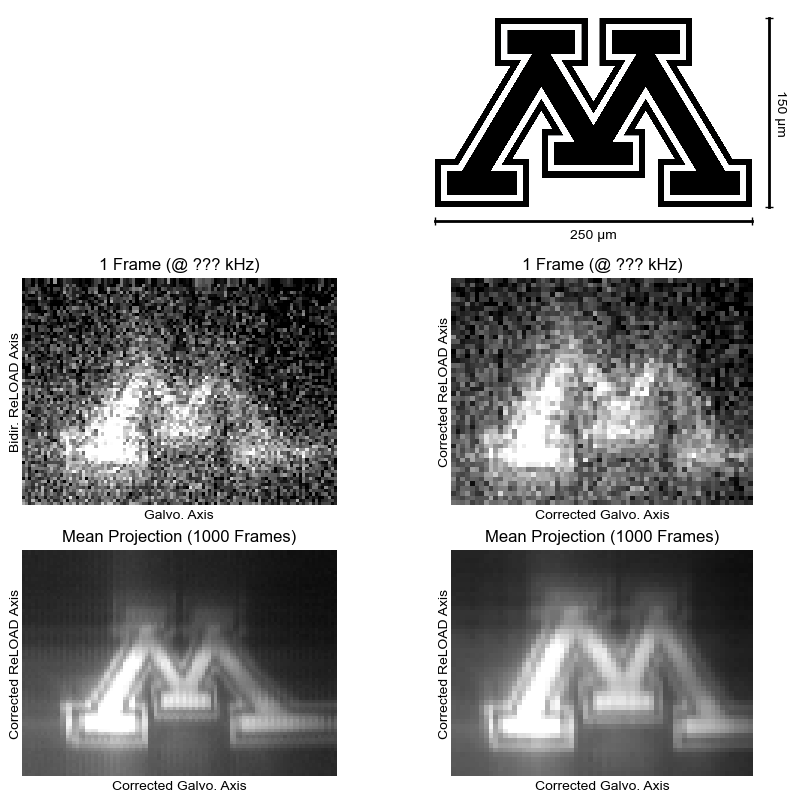

In [28]:
t = 0
minVal = 0
maxVal = 75
#################################
fig,ax = plt.subplots(3,2,figsize = (10,10))
fig.delaxes(ax[0,0])
ax[0,1].imshow(refImg,interpolation='none')
ax[0,1].plot([0,1800],[1150,1150],'|-',lw=2,color=(0,0,0))
ax[0,1].text(1800/2,1200, "250 μm",color=(0,0,0),ha='center',va='top')
ax[0,1].plot([1900,1900],[0,1071],'_-',lw=2,color=(0,0,0))
ax[0,1].text(1925,1071/2, "150 μm",color=(0,0,0),rotation=-90,ha='left',va='center')

ax[0,1].set_xlim([-50, 1950])
ax[0,1].set_ylim([1200,-50])
ax[0,1]=sled_image_tools.imshow_cleanup(ax[0,1])
#################################
im = ax[1,0].imshow(data_EOD_Shifted_pad_crop_reorient_resize[t,:,:],\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[1,0].set_title("1 Frame (@ ??? kHz)",fontsize=12,color=(0,0,0))
ax[1,0]=sled_image_tools.imshow_cleanup(ax[1,0])
xlim =ax[1,0].get_xlim() 
ylim =ax[1,0].get_ylim() 
ax[1,0].text(xlim[0],ylim[1]-(ylim[1]-ylim[0])/2,'Bidir. ReLOAD Axis',rotation = 90,ha='right',va='center')
ax[1,0].text(xlim[1]-(xlim[1]-xlim[0])/2,ylim[0]-(ylim[1]-ylim[0])*0.02,'Galvo. Axis',ha='center',va='top')
#################################
im = ax[2,0].imshow(data_EOD_Shifted_pad_meanProj_crop_reorient,\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[2,0].set_title("Mean Projection ("+str(data_EOD_Shifted_pad_crop_reorient.shape[0])+" Frames)",fontsize=12,color=(0,0,0))
xlim =ax[2,0].get_xlim() 
ylim =ax[2,0].get_ylim() 
ax[2,0].text(xlim[0],ylim[1]-(ylim[1]-ylim[0])/2,'Corrected ReLOAD Axis',rotation = 90,ha='right',va='center')
ax[2,0].text(xlim[1]-(xlim[1]-xlim[0])/2,ylim[0]-(ylim[1]-ylim[0])*0.02,'Corrected Galvo. Axis',ha='center',va='top')
ax[2,0]=sled_image_tools.imshow_cleanup(ax[2,0])
#################################
im = ax[1,1].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient[t,:,:],\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[1,1].set_title("1 Frame (@ ??? kHz)",fontsize=12,color=(0,0,0))
ax[1,1]=sled_image_tools.imshow_cleanup(ax[1,1])
xlim =ax[1,1].get_xlim() 
ylim =ax[1,1].get_ylim() 
ax[1,1].text(xlim[0],ylim[1]-(ylim[1]-ylim[0])/2,'Corrected ReLOAD Axis',rotation = 90,ha='right',va='center')
ax[1,1].text(xlim[1]-(xlim[1]-xlim[0])/2,ylim[0]-(ylim[1]-ylim[0])*0.02,'Corrected Galvo. Axis',ha='center',va='top')
#################################
im = ax[2,1].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient,\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[2,1].set_title("Mean Projection ("+str(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape[0])+" Frames)",fontsize=12,color=(0,0,0))
xlim =ax[2,1].get_xlim() 
ylim =ax[2,1].get_ylim() 
ax[2,1].text(xlim[0],ylim[1]-(ylim[1]-ylim[0])/2,'Corrected ReLOAD Axis',rotation = 90,ha='right',va='center')
ax[2,1].text(xlim[1]-(xlim[1]-xlim[0])/2,ylim[0]-(ylim[1]-ylim[0])*0.02,'Corrected Galvo. Axis',ha='center',va='top')
ax[2,1]=sled_image_tools.imshow_cleanup(ax[2,1])
#################################

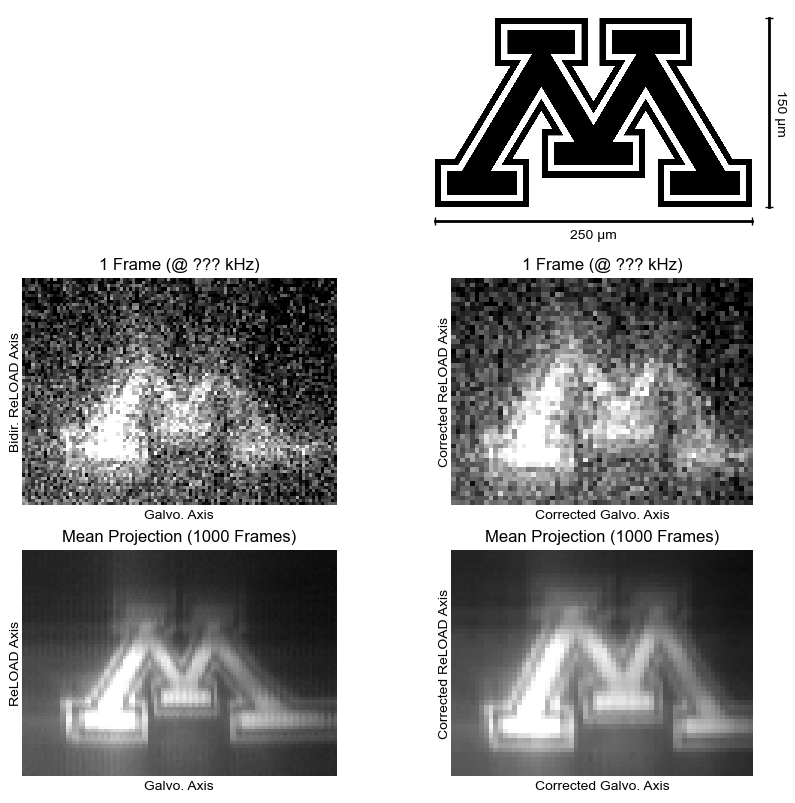

In [29]:
t = 0
minVal = 0
maxVal = 75
#################################
fig,ax = plt.subplots(3,2,figsize = (10,10))
fig.delaxes(ax[0,0])
ax[0,1].imshow(refImg,interpolation='none')
ax[0,1].plot([0,1800],[1150,1150],'|-',lw=2,color=(0,0,0))
ax[0,1].text(1800/2,1200, "250 μm",color=(0,0,0),ha='center',va='top')
ax[0,1].plot([1900,1900],[0,1071],'_-',lw=2,color=(0,0,0))
ax[0,1].text(1925,1071/2, "150 μm",color=(0,0,0),rotation=-90,ha='left',va='center')

ax[0,1].set_xlim([-50, 1950])
ax[0,1].set_ylim([1200,-50])
ax[0,1]=sled_image_tools.imshow_cleanup(ax[0,1])
#################################
im = ax[1,0].imshow(data_EOD_Shifted_crop_reorient_resize[t,:,:],\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[1,0].set_title("1 Frame (@ ??? kHz)",fontsize=12,color=(0,0,0))
ax[1,0]=sled_image_tools.imshow_cleanup(ax[1,0])
xlim =ax[1,0].get_xlim() 
ylim =ax[1,0].get_ylim() 
ax[1,0].text(xlim[0],ylim[1]-(ylim[1]-ylim[0])/2,'Bidir. ReLOAD Axis',rotation = 90,ha='right',va='center')
ax[1,0].text(xlim[1]-(xlim[1]-xlim[0])/2,ylim[0]-(ylim[1]-ylim[0])*0.02,'Galvo. Axis',ha='center',va='top')
#################################
im = ax[2,0].imshow(data_EOD_Shifted_meanProj_crop_reorient,\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[2,0].set_title("Mean Projection ("+str(data_EOD_Shifted_crop_reorient.shape[0])+" Frames)",fontsize=12,color=(0,0,0))
xlim =ax[2,0].get_xlim() 
ylim =ax[2,0].get_ylim() 
ax[2,0].text(xlim[0],ylim[1]-(ylim[1]-ylim[0])/2,'ReLOAD Axis',rotation = 90,ha='right',va='center')
ax[2,0].text(xlim[1]-(xlim[1]-xlim[0])/2,ylim[0]-(ylim[1]-ylim[0])*0.02,'Galvo. Axis',ha='center',va='top')
ax[2,0]=sled_image_tools.imshow_cleanup(ax[2,0])
#################################
im = ax[1,1].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient[t,:,:],\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[1,1].set_title("1 Frame (@ ??? kHz)",fontsize=12,color=(0,0,0))
ax[1,1]=sled_image_tools.imshow_cleanup(ax[1,1])
xlim =ax[1,1].get_xlim() 
ylim =ax[1,1].get_ylim() 
ax[1,1].text(xlim[0],ylim[1]-(ylim[1]-ylim[0])/2,'Corrected ReLOAD Axis',rotation = 90,ha='right',va='center')
ax[1,1].text(xlim[1]-(xlim[1]-xlim[0])/2,ylim[0]-(ylim[1]-ylim[0])*0.02,'Corrected Galvo. Axis',ha='center',va='top')
#################################
im = ax[2,1].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient,\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[2,1].set_title("Mean Projection ("+str(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape[0])+" Frames)",fontsize=12,color=(0,0,0))
xlim =ax[2,1].get_xlim() 
ylim =ax[2,1].get_ylim() 
ax[2,1].text(xlim[0],ylim[1]-(ylim[1]-ylim[0])/2,'Corrected ReLOAD Axis',rotation = 90,ha='right',va='center')
ax[2,1].text(xlim[1]-(xlim[1]-xlim[0])/2,ylim[0]-(ylim[1]-ylim[0])*0.02,'Corrected Galvo. Axis',ha='center',va='top')
ax[2,1]=sled_image_tools.imshow_cleanup(ax[2,1])
#################################

10


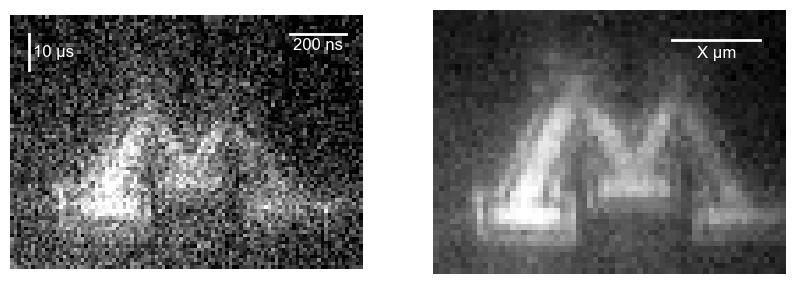

In [30]:
t = 0
meanRange=list(range(0,10))
print(len(meanRange))
minVal = 0
maxVal = 90
fig,ax = plt.subplots(1,2,figsize = (10,10))
im = ax[0].imshow(data_EOD_Shifted_crop_reorient_resize[t,:,:],\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[0].plot([5,5],[5,15],lw=2,color=(1,1,1))
ax[0].text(6,10,'10 μs',color=(1,1,1),fontsize=12,ha='left',va='center')
ax[0].plot([data_EOD_Shifted_crop_reorient_resize.shape[2]-5,data_EOD_Shifted_crop_reorient_resize.shape[2]-21],[5,5],lw=2,color=(1,1,1))
ax[0].text(data_EOD_Shifted_crop_reorient_resize.shape[2]-13,6,'200 ns',color=(1,1,1),fontsize=12,ha='center',va='top')
ax[0]=sled_image_tools.imshow_cleanup(ax[0])
im = ax[1].imshow(np.nanmean(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient[meanRange,:,:],axis=0),\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[1].plot([data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape[2]-5,data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape[2]-21],[5,5],lw=2,color=(1,1,1))
ax[1].text(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape[2]-13,6,'X μm',color=(1,1,1),fontsize=12,ha='center',va='top')
ax[1]=sled_image_tools.imshow_cleanup(ax[1])


100


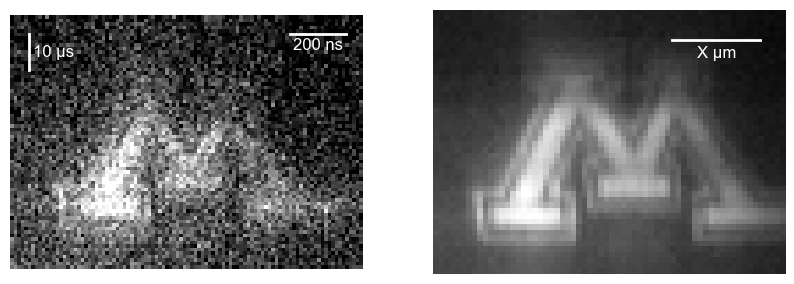

In [34]:
t = 0
meanRange=list(range(0,100))
print(len(meanRange))
minVal = 0
maxVal = 90
fig,ax = plt.subplots(1,2,figsize = (10,10))
im = ax[0].imshow(data_EOD_Shifted_crop_reorient_resize[t,:,:],\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[0].plot([5,5],[5,15],lw=2,color=(1,1,1))
ax[0].text(6,10,'10 μs',color=(1,1,1),fontsize=12,ha='left',va='center')
ax[0].plot([data_EOD_Shifted_crop_reorient_resize.shape[2]-5,data_EOD_Shifted_crop_reorient_resize.shape[2]-21],[5,5],lw=2,color=(1,1,1))
ax[0].text(data_EOD_Shifted_crop_reorient_resize.shape[2]-13,6,'200 ns',color=(1,1,1),fontsize=12,ha='center',va='top')
ax[0]=sled_image_tools.imshow_cleanup(ax[0])
im = ax[1].imshow(np.nanmean(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient[meanRange,:,:],axis=0),\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[1].plot([data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape[2]-5,data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape[2]-21],[5,5],lw=2,color=(1,1,1))
ax[1].text(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape[2]-13,6,'X μm',color=(1,1,1),fontsize=12,ha='center',va='top')
ax[1]=sled_image_tools.imshow_cleanup(ax[1])


In [54]:
figDir = '/mnt/c/scratch/EOD_250822/'
figName = 'upscale_100fr_meanProj.pdf'

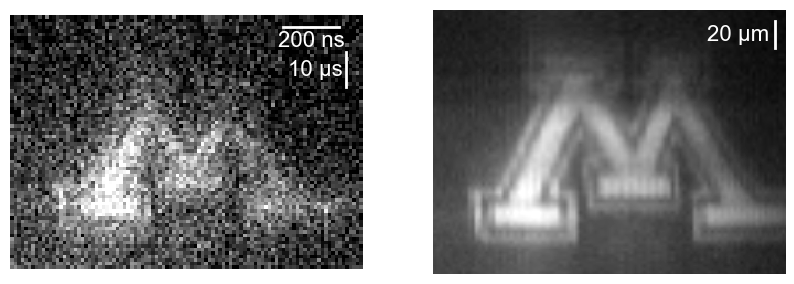

In [55]:
t = 0
y_um_px = 148.75/856.8
fontsize = 16
meanRange=list(range(0,100))
minVal = 0
maxVal = 90
fig,ax = plt.subplots(1,2,figsize = (10,10))
im = ax[0].imshow(data_EOD_Shifted_crop_reorient_resize[t,:,:],\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[0].plot([data_EOD_Shifted_crop_reorient_resize.shape[2]-5,data_EOD_Shifted_crop_reorient_resize.shape[2]-5],[10,20],lw=2,color=(1,1,1))
ax[0].text(data_EOD_Shifted_crop_reorient_resize.shape[2]-6,15,'10 μs',color=(1,1,1),fontsize=fontsize,ha='right',va='center')
ax[0].plot([data_EOD_Shifted_crop_reorient_resize.shape[2]-7,data_EOD_Shifted_crop_reorient_resize.shape[2]-23],[3,3],lw=2,color=(1,1,1))
ax[0].text(data_EOD_Shifted_crop_reorient_resize.shape[2]-15,4,'200 ns',color=(1,1,1),fontsize=fontsize,ha='center',va='top')
ax[0]=sled_image_tools.imshow_cleanup(ax[0])
im = ax[1].imshow(np.nanmean(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient[meanRange,:,:],axis=0),\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[1].plot([data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient.shape[2]-10,data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient.shape[2]-10],[10,34],lw=2,color=(1,1,1))
ax[1].text(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient.shape[2]-15,22,'20 μm',color=(1,1,1),fontsize=fontsize,ha='right',va='center')
# ax[1].plot([data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient.shape[2]-25,data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient.shape[2]-105],[25,25],lw=2,color=(1,1,1))
# ax[1].text(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient.shape[2]-65,30,'X μm',color=(1,1,1),fontsize=12,ha='center',va='top')
ax[1]=sled_image_tools.imshow_cleanup(ax[1])
with PdfPages(os.path.join(figDir,figName)) as pdf:
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


In [47]:
180/150

1.2

In [51]:
20*1.2

24.0

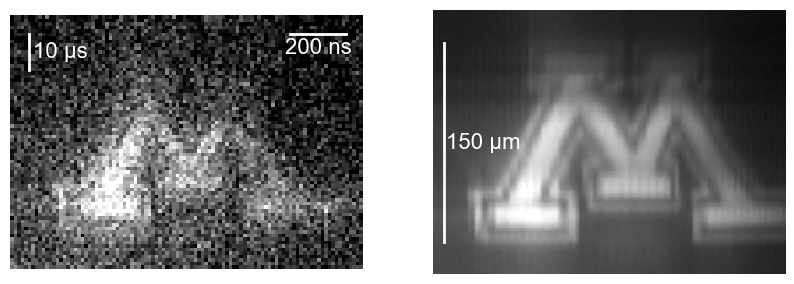

In [33]:
t = 0
y_um_px = 148.75/856.8
fontsize = 16
meanRange=list(range(0,1000))
minVal = 0
maxVal = 90
fig,ax = plt.subplots(1,2,figsize = (10,10))
im = ax[0].imshow(data_EOD_Shifted_crop_reorient_resize[t,:,:],\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[0].plot([5,5],[5,15],lw=2,color=(1,1,1))
ax[0].text(6,10,'10 μs',color=(1,1,1),fontsize=fontsize,ha='left',va='center')
ax[0].plot([data_EOD_Shifted_crop_reorient_resize.shape[2]-5,data_EOD_Shifted_crop_reorient_resize.shape[2]-21],[5,5],lw=2,color=(1,1,1))
ax[0].text(data_EOD_Shifted_crop_reorient_resize.shape[2]-13,6,'200 ns',color=(1,1,1),fontsize=fontsize,ha='center',va='top')
ax[0]=sled_image_tools.imshow_cleanup(ax[0])
im = ax[1].imshow(np.nanmean(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient[meanRange,:,:],axis=0),\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[1].plot([10,10],[30,210],lw=2,color=(1,1,1))
ax[1].text(12,120,'150 μm',color=(1,1,1),fontsize=fontsize,ha='left',va='center')
# ax[1].plot([data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient.shape[2]-25,data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient.shape[2]-105],[25,25],lw=2,color=(1,1,1))
# ax[1].text(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient.shape[2]-65,30,'X μm',color=(1,1,1),fontsize=12,ha='center',va='top')
ax[1]=sled_image_tools.imshow_cleanup(ax[1])


# <font size="5">Movie/GIF

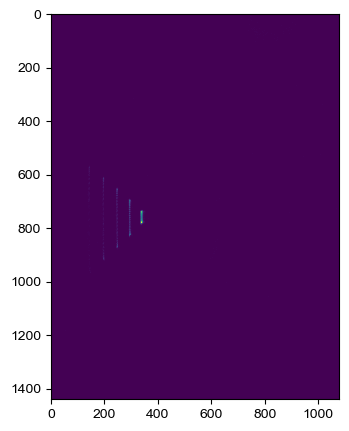

In [26]:
plt.figure(figsize = (5,5))
plt.imshow(scanImg,interpolation='none')

In [71]:
def smart_float2str(val,decimals=1):
    val = str(np.round(val,decimals = decimals))
    if decimals > 0:
        if not '.' in val:
            val = val+'.'
        while len(val.split('.')[-1]) < decimals:
            val = val+'0'
    return val

def read_fig_image(fig,dpi,bbox = 'none'):
    b = BytesIO()
    if bbox == 'tight':
        fig.savefig(b, format='png', dpi=dpi,bbox_inches='tight')
    else:
        fig.savefig(b, format='png', dpi=dpi)
    
    # Read back from byte stream
    b.seek(0)
    image = plt.imread(b)
    image = image[:,:,0:3]*255
    image = image.astype('uint8')
    # Dispose of the stream to save memory
    b.close()
    del b
    # canvas.draw()  # Draw the canvas, cache the renderer
    
    # image_flat = np.frombuffer(canvas.tostring_rgb(), dtype='uint8')  # (H * W * 3,)
    # # NOTE: reversed converts (W, H) from get_width_height to (H, W)
    # image = image_flat.reshape(*reversed(canvas.get_width_height()), 3)  # (H, W, 3)
    return image


In [89]:
def ReLOAD_movie_panel(i,display,target_aspect_ratio):
    fig,ax = plt.subplots(1,2,figsize = figsize)
    im1 = ax[0].imshow(scanImg_crop,interpolation='none',\
                       vmin=minVal1,vmax=maxVal1,cmap='inferno')
    ax[0].text(25,scanImg_crop.shape[0]-5,"1",color = (1,1,1),fontsize=fontsize,va='bottom',ha='center')
    ax[0].text(75,scanImg_crop.shape[0]-5,"2",color = (1,1,1),fontsize=fontsize,va='bottom',ha='center')
    ax[0].text(125,scanImg_crop.shape[0]-5,"3",color = (1,1,1),fontsize=fontsize,va='bottom',ha='center')
    ax[0].text(175,scanImg_crop.shape[0]-5,"4",color = (1,1,1),fontsize=fontsize,va='bottom',ha='center')
    # ax[0]=sled_image_tools.imshow_cleanup(ax[0])
    ax[0].set_yticks([])
    ax[0].set_xticks([])
    ax[0].set_title('EO-ReLOAD',color = (0,0,0),fontsize=fontsize)
    ax[0].set_xlabel('Loop Number',color = (0,0,0),fontsize=fontsize)
    ax[0].set_ylabel('EOD Scan Axis',color = (0,0,0),fontsize=fontsize)
    
    im2 = ax[1].imshow(data_EOD_Shifted_crop_reorient_resize[i,:,:],\
                        vmin = minVal2,vmax = maxVal2,interpolation='none',cmap = 'gray')
    txt=ax[1].text(data_EOD_Shifted_crop_reorient_resize.shape[2]-4,3,smart_float2str(i*0.1)+" ms",color = (1,1,1),fontsize=fontsize,va='top',ha='right')
    # ax[1]=sled_image_tools.imshow_cleanup(ax[1])
    ax[1].set_yticks([])
    ax[1].set_xticks([])
    ax[1].set_xlabel('Galvo. Scan Axis',color = (0,0,0),fontsize=fontsize)
    ax[1].set_ylabel('EOD Scan Axis',color = (0,0,0),fontsize=fontsize)
    ax[1].set_title("1 MHz Line Rate",color = (0,0,0),fontsize=fontsize)
    # ax[1].plot([5,5],[5,15],lw=2,color=(1,1,1))
    # ax[1].text(6,10,'10 μs',color=(1,1,1),fontsize=fontsize,ha='left',va='center')
    # ax[1].plot([data_EOD_Shifted_crop_reorient_resize.shape[2]-5,data_EOD_Shifted_crop_reorient_resize.shape[2]-21],[5,5],lw=2,color=(1,1,1))
    # ax[1].text(data_EOD_Shifted_crop_reorient_resize.shape[2]-13,6,'200 ns',color=(1,1,1),fontsize=fontsize,ha='center',va='top')
    # ax[1].plot([data_EOD_Shifted_crop_reorient_resize.shape[2]-10,data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient.shape[2]-10],[10,34],lw=2,color=(1,1,1))
    # ax[1].text(data_EOD_Shifted_crop_reorient_resize.shape[2]-15,22,'20 μm',color=(1,1,1),fontsize=fontsize,ha='right',va='center')
    ######################
    pos1 = ax[0].get_position()
    pos2 = ax[1].get_position()
    ax[0].set_position([pos1.x0+0.06, pos1.y0+0.07, pos1.width, pos1.height-0.16])
    ax[1].set_position([pos2.x0-0.06, pos2.y0, pos2.width, pos2.height])
    image = read_fig_image(fig,dpi,'tight')
    original_height = image.shape[0]
    original_width = image.shape[1]
    
    background_color = (0,0,0)
    current_aspect_ratio = original_width / original_height

    if original_width / original_height > target_aspect_ratio:  # Image is wider than 16:9
        new_height = int(original_width / target_aspect_ratio)
        padding_top = (new_height - original_height) // 2
        padding_bottom = new_height - original_height - padding_top
        padding_left = 0
        padding_right = 0
    else:  # Image is taller than 16:9
        new_width = int(original_height * target_aspect_ratio)
        padding_left = (new_width - original_width) // 2
        padding_right = new_width - original_width - padding_left
        padding_top = 0
        padding_bottom = 0
    
    padded_image = np.pad(image,((padding_top,padding_bottom),(padding_left,padding_right),(0,0)),'constant', constant_values=255)
    
    if display:
        print(image.shape)
        print(f'padding_top = {padding_top}')
        print(f'padding_bottom = {padding_bottom}')
    
        print(f'padding_left = {padding_left}')
        print(f'padding_right = {padding_right}')
        print(padded_image.shape)
        plt.show()
    else:
        plt.close()
    return padded_image

(237, 374, 3)
padding_top = 0
padding_bottom = 0
padding_left = 39
padding_right = 39
(237, 452, 3)


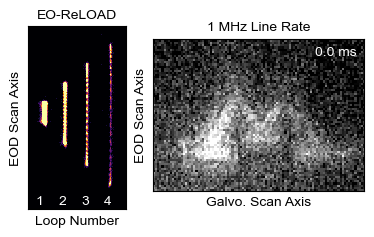

(100, 237, 452, 3)


In [90]:
scanImg_crop = np.fliplr(np.array(scanImg)[570:970,160:375])
figsize = (6,3)
target_aspect_ratio = 16 / 9
target_aspect_ratio = 1.91 / 1
fontsize = 10
dpi = 100
nFr = data_EOD_Shifted_crop_reorient_resize.shape[0]
nFr = 100
minVal1 = 0
maxVal1 = 20
minVal2 = 0
maxVal2 = 90
i=0
image = ReLOAD_movie_panel(i,True,target_aspect_ratio)
movie = np.zeros((nFr,image.shape[0],image.shape[1],image.shape[2]),dtype='uint8')
print(movie.shape)

In [91]:
sled_general_tools.memory_cleanup(False)


In [92]:
with tqdm(total=nFr) as pbar:
    for i in range(nFr):
        movie[i,:,:,:] = ReLOAD_movie_panel(i,False,target_aspect_ratio)
        pbar.update(1)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 22.77it/s]


In [93]:
frameRate = 60
figDir = '/mnt/c/scratch/EOD_250822/'
movieName = "ReLOAD_1p91_1"
output_frame_size =  (int(movie.shape[2]),int(movie.shape[1]))
vidObj = cv2.VideoWriter(os.path.join(figDir,movieName+".avi"),\
                        cv2.VideoWriter_fourcc(*'MJPG'),int(frameRate),output_frame_size)
time.sleep(0.1)
with tqdm(total=nFr) as pbar:
    for fr in range(nFr):
        frame2_RGB = copy.deepcopy(movie[fr,:,:,:])
        # frame2_RGB=np.uint8(frame2_RGB[:,:,:3] * 255)
        frame2_RGB = cv2.resize(frame2_RGB, dsize=output_frame_size)
        frame2_RGB=cv2.cvtColor(frame2_RGB, cv2.COLOR_RGB2BGR)
        vidObj.write(frame2_RGB)
        pbar.update(1)
vidObj.release()
cv2.destroyAllWindows()
del vidObj


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 725.30it/s]


In [94]:
# Load the AVI video clip
video_clip = VideoFileClip.VideoFileClip(os.path.join(figDir,movieName+".avi"))

In [95]:
# Write the clip as a GIF
video_clip.write_gif(os.path.join(figDir,movieName+".gif"),fps = frameRate)

MoviePy - Building file /mnt/c/scratch/EOD_250822/ReLOAD_1p91_1.gif with imageio.


In [35]:
VideoFileClip

<module 'moviepy.video.io.VideoFileClip' from '/home/newmanza/anaconda3/lib/python3.12/site-packages/moviepy/video/io/VideoFileClip.py'>

In [75]:
video_clip.fps

100.0

In [77]:
gif_clip.load_gif(os.path.join(figDir,movieName".gif"))

NameError: name 'gif_clip' is not defined

In [78]:
gif_clip = VideoFileClip.VideoFileClip(os.path.join(figDir,movieName+".gif"))

In [79]:
gif_clip.fps

100.0

In [151]:
from PIL import Image
pil_image = Image.fromarray(movie)


TypeError: Cannot handle this data type: (1, 1, 763, 3), |u1

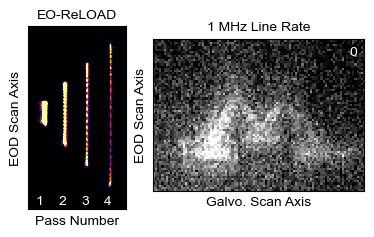

In [126]:
frameRate = 1000


fig,ax = plt.subplots(1,2,figsize = figsize)
im1 = ax[0].imshow(scanImg_crop,interpolation='none',\
                   vmin=minVal1,vmax=maxVal1,cmap='inferno')
ax[0].text(25,scanImg_crop.shape[0]-5,"1",color = (1,1,1),fontsize=10,va='bottom',ha='center')
ax[0].text(75,scanImg_crop.shape[0]-5,"2",color = (1,1,1),fontsize=10,va='bottom',ha='center')
ax[0].text(125,scanImg_crop.shape[0]-5,"3",color = (1,1,1),fontsize=10,va='bottom',ha='center')
ax[0].text(175,scanImg_crop.shape[0]-5,"4",color = (1,1,1),fontsize=10,va='bottom',ha='center')
# ax[0]=sled_image_tools.imshow_cleanup(ax[0])
ax[0].set_yticks([])
ax[0].set_xticks([])
ax[0].set_title('EO-ReLOAD',color = (0,0,0),fontsize=10)
ax[0].set_xlabel('Pass Number',color = (0,0,0),fontsize=10)
ax[0].set_ylabel('EOD Scan Axis',color = (0,0,0),fontsize=10)

im2 = ax[1].imshow(data_EOD_Shifted_crop_reorient_resize[i,:,:],\
                    vmin = minVal2,vmax = maxVal2,interpolation='none',cmap = 'gray')
txt=ax[1].text(data_EOD_Shifted_crop_reorient_resize.shape[2]-4,3,i,color = (1,1,1),fontsize=10,va='top',ha='right')
# ax[1]=sled_image_tools.imshow_cleanup(ax[1])
ax[1].set_yticks([])
ax[1].set_xticks([])
ax[1].set_xlabel('Galvo. Scan Axis',color = (0,0,0),fontsize=10)
ax[1].set_ylabel('EOD Scan Axis',color = (0,0,0),fontsize=10)
ax[1].set_title("1 MHz Line Rate",color = (0,0,0),fontsize=10)
pos1 = ax[0].get_position()
pos2 = ax[1].get_position()
ax[0].set_position([pos1.x0+0.06, pos1.y0+0.07, pos1.width, pos1.height-0.16])
ax[1].set_position([pos2.x0-0.06, pos2.y0, pos2.width, pos2.height])

def init():
    im2.set_data(data_EOD_Shifted_crop_reorient_resize[0,:,:])
    return im2,

def animate(i):
    im2.set_data(data_EOD_Shifted_crop_reorient_resize[i,:,:])
    txt.set_text(i)
    return im2,txt

ani = animation.FuncAnimation(fig, animate, frames=data_EOD_Shifted_crop_reorient_resize.shape[0], interval=0.0001, init_func = init, blit=True, repeat=True)
plt.show()

In [127]:
figDir = '/mnt/c/scratch/EOD_250822/'
ani.save(os.path.join(figDir,'animation.gif'), writer='pillow', fps=1000)


In [ ]:
    movieParams['input_frame_size'] = (movie.shape[2],movie.shape[1])
    nFr = movie.shape[0]
    movieParams['output_frame_size'] = (int(np.round(movie.shape[2]*movieParams['exportScalar'])),int(np.round(movie.shape[1]*movieParams['exportScalar'])))
    print("Export Size: "+str(movieParams['input_frame_size'])+" --x"+str(movieParams['exportScalar'])+"--> "+str(movieParams['output_frame_size'])+" FPS = "+str(movieParams['exportFPS']))
    
    if 'avi' in movieParams['exportFormats']:
        if os.path.exists(os.path.join(movieParams['movieScratchDir'],movieParams['saveName']+".avi")):
            print("REMOVING PREVIOUS SCRATCH: "+movieParams['saveName']+".avi",end='...')
            os.remove(os.path.join(movieParams['movieScratchDir'],movieParams['saveName']+".avi"))
            print("Finished!")
    ############################################
    if 'avi' in movieParams['exportFormats']:
        vidObj = cv2.VideoWriter(os.path.join(movieParams['movieScratchDir'],movieParams['saveName']+".avi"),\
                                cv2.VideoWriter_fourcc(*'MJPG'),int(movieParams['exportFPS']),movieParams['output_frame_size'])
        time.sleep(0.1)
        with tqdm(total=nFr) as pbar:
            for fr in range(nFr):
                frame2_RGB = copy.deepcopy(movie[fr,:,:,:])
                # frame2_RGB=np.uint8(frame2_RGB[:,:,:3] * 255)
                frame2_RGB = cv2.resize(frame2_RGB, dsize=movieParams['output_frame_size'])
                frame2_RGB=cv2.cvtColor(frame2_RGB, cv2.COLOR_RGB2BGR)
                vidObj.write(frame2_RGB)
                pbar.update(1)
        vidObj.release()
        cv2.destroyAllWindows()
        del vidObj


    ############################################
